In [1]:
# Import packages
from pathlib import Path
import XvP_utils as plotting

ANALYSIS_NAME = "Analysis_2"
ctx = plotting.notebook_context(ANALYSIS_NAME, 'standard')
PROJECT_DIR = ctx.project_dir
SPECIES = ctx.species
INDEX_DIR = ctx.index_dir
CUTOFFS = ctx.knee('sampled', ['10x', 'polyT', 'randO', 'parse'])
ANALYSIS_DIR = Path.cwd()
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons.csv")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc

import XvP_utils as plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics', type='standard')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
# plotting.upsample(raw_datasets, Path("preseq/standard"), overwrite=False)
# plotting.plot_upsample(raw_datasets, Path("preseq/standard"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

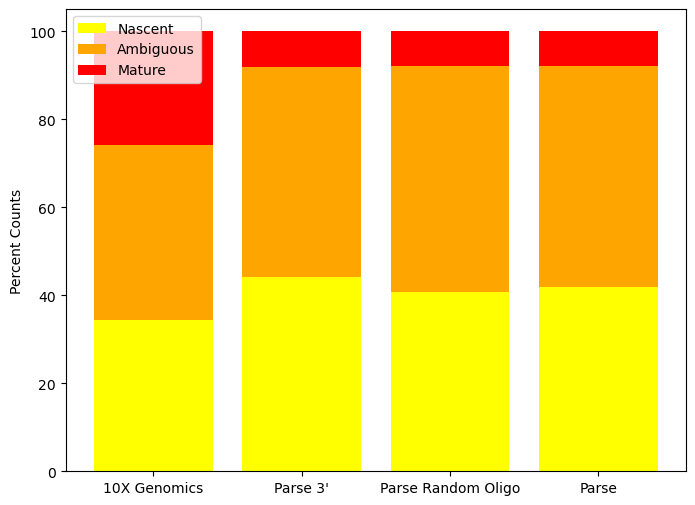

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

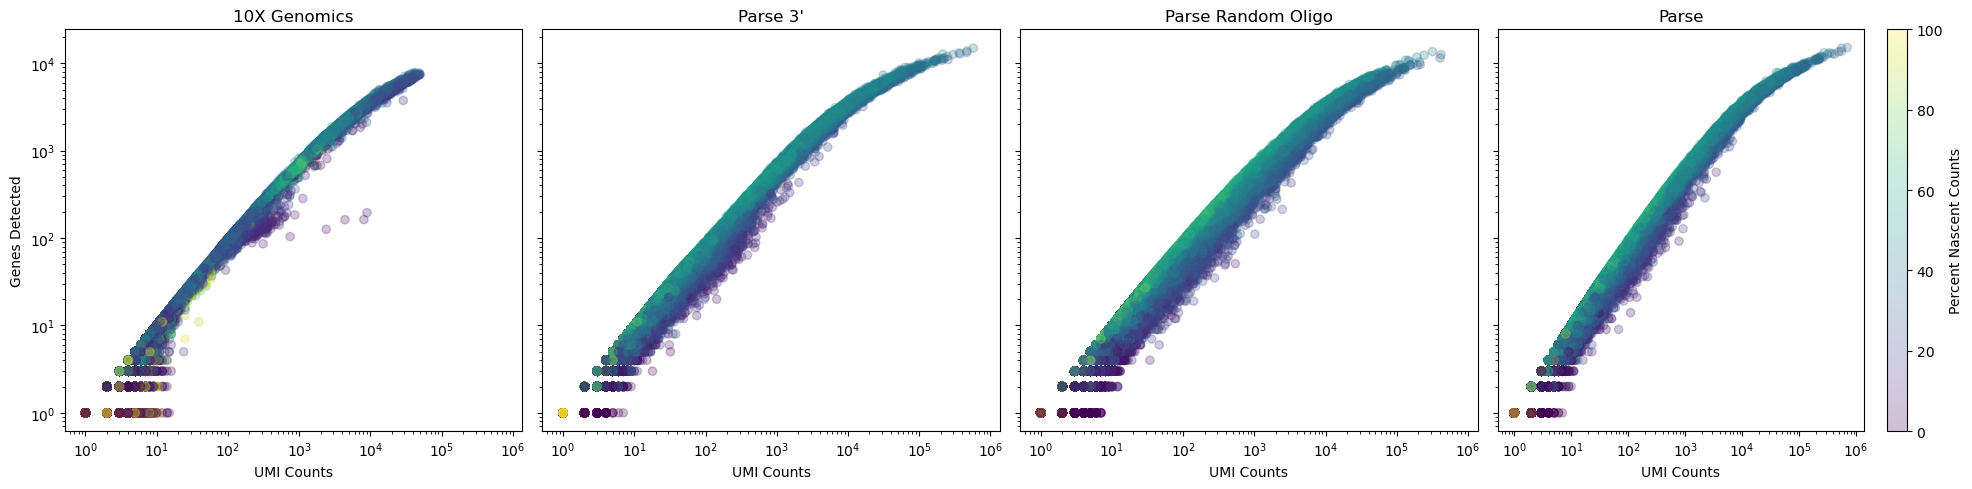

In [8]:
plotting.scatter_reads(raw_datasets)

In [9]:
gene_info = plotting.query_ensembl(PROJECT_DIR, index_dir=INDEX_DIR, species=SPECIES, overwrite=False)

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


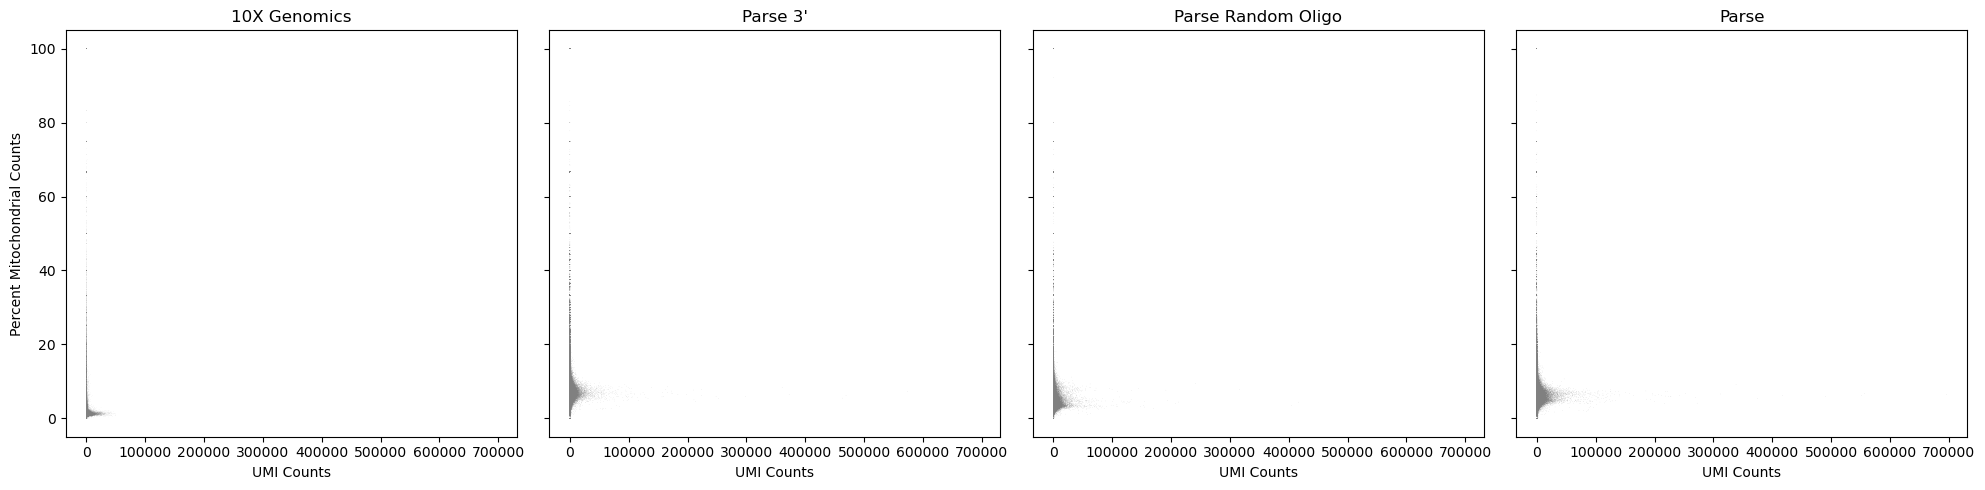

In [11]:
plotting.mito_scatter(raw_datasets)

13,040 cells passed the 1000 UMI threshold for 10X Genomics
40,824 cells passed the 400 UMI threshold for Parse 3'
38,499 cells passed the 400 UMI threshold for Parse Random Oligo
42,944 cells passed the 400 UMI threshold for Parse


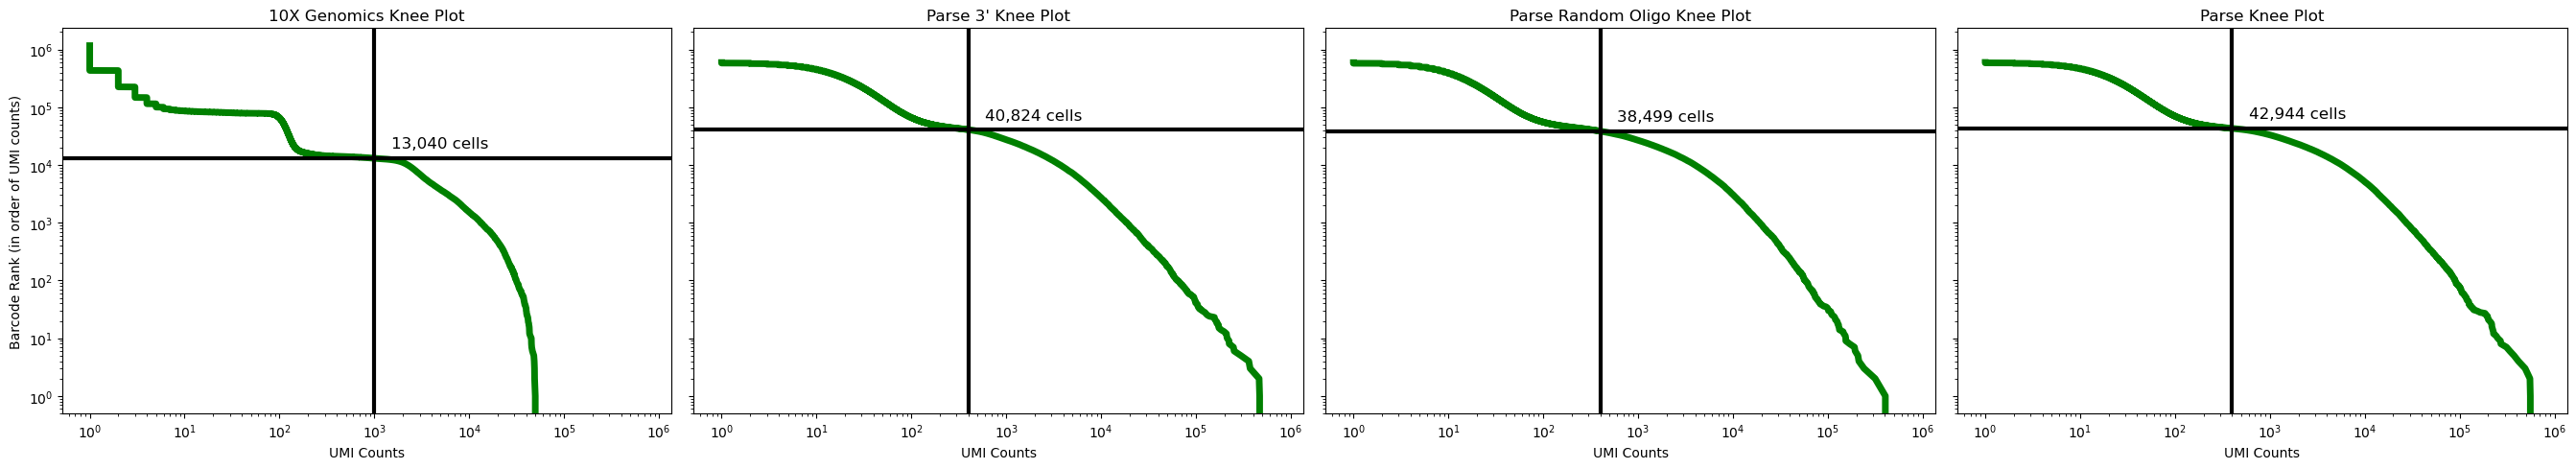

In [12]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS)

In [13]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

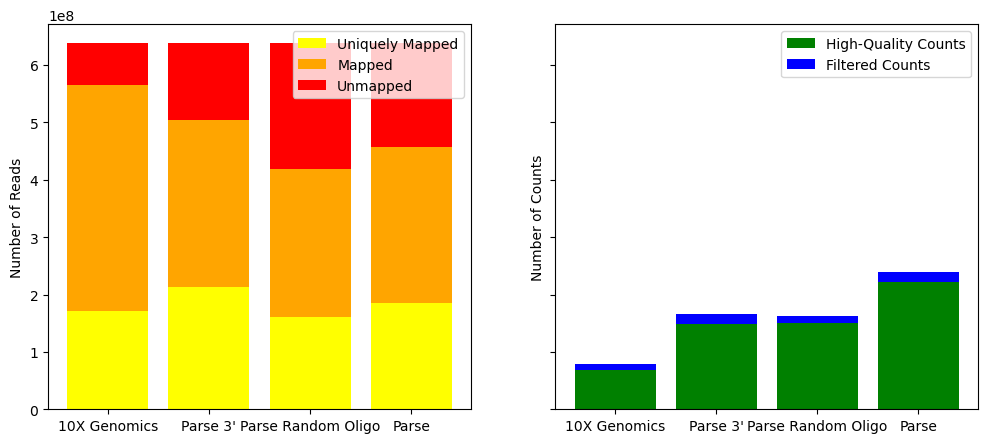

In [14]:
plotting.plot_filtering_metrics(datasets)

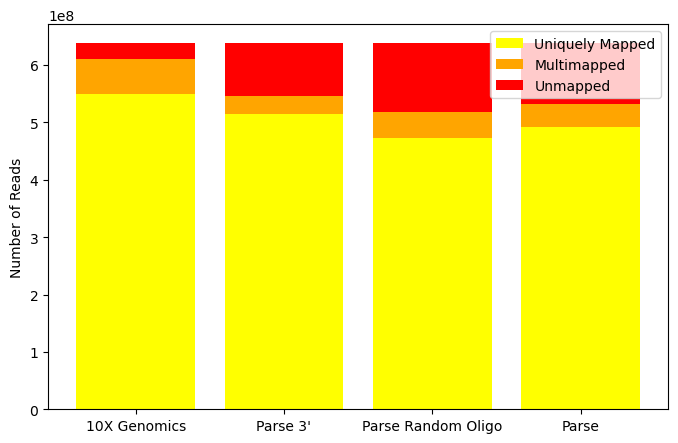

In [15]:
plotting.plot_filtering_metrics_star(datasets)

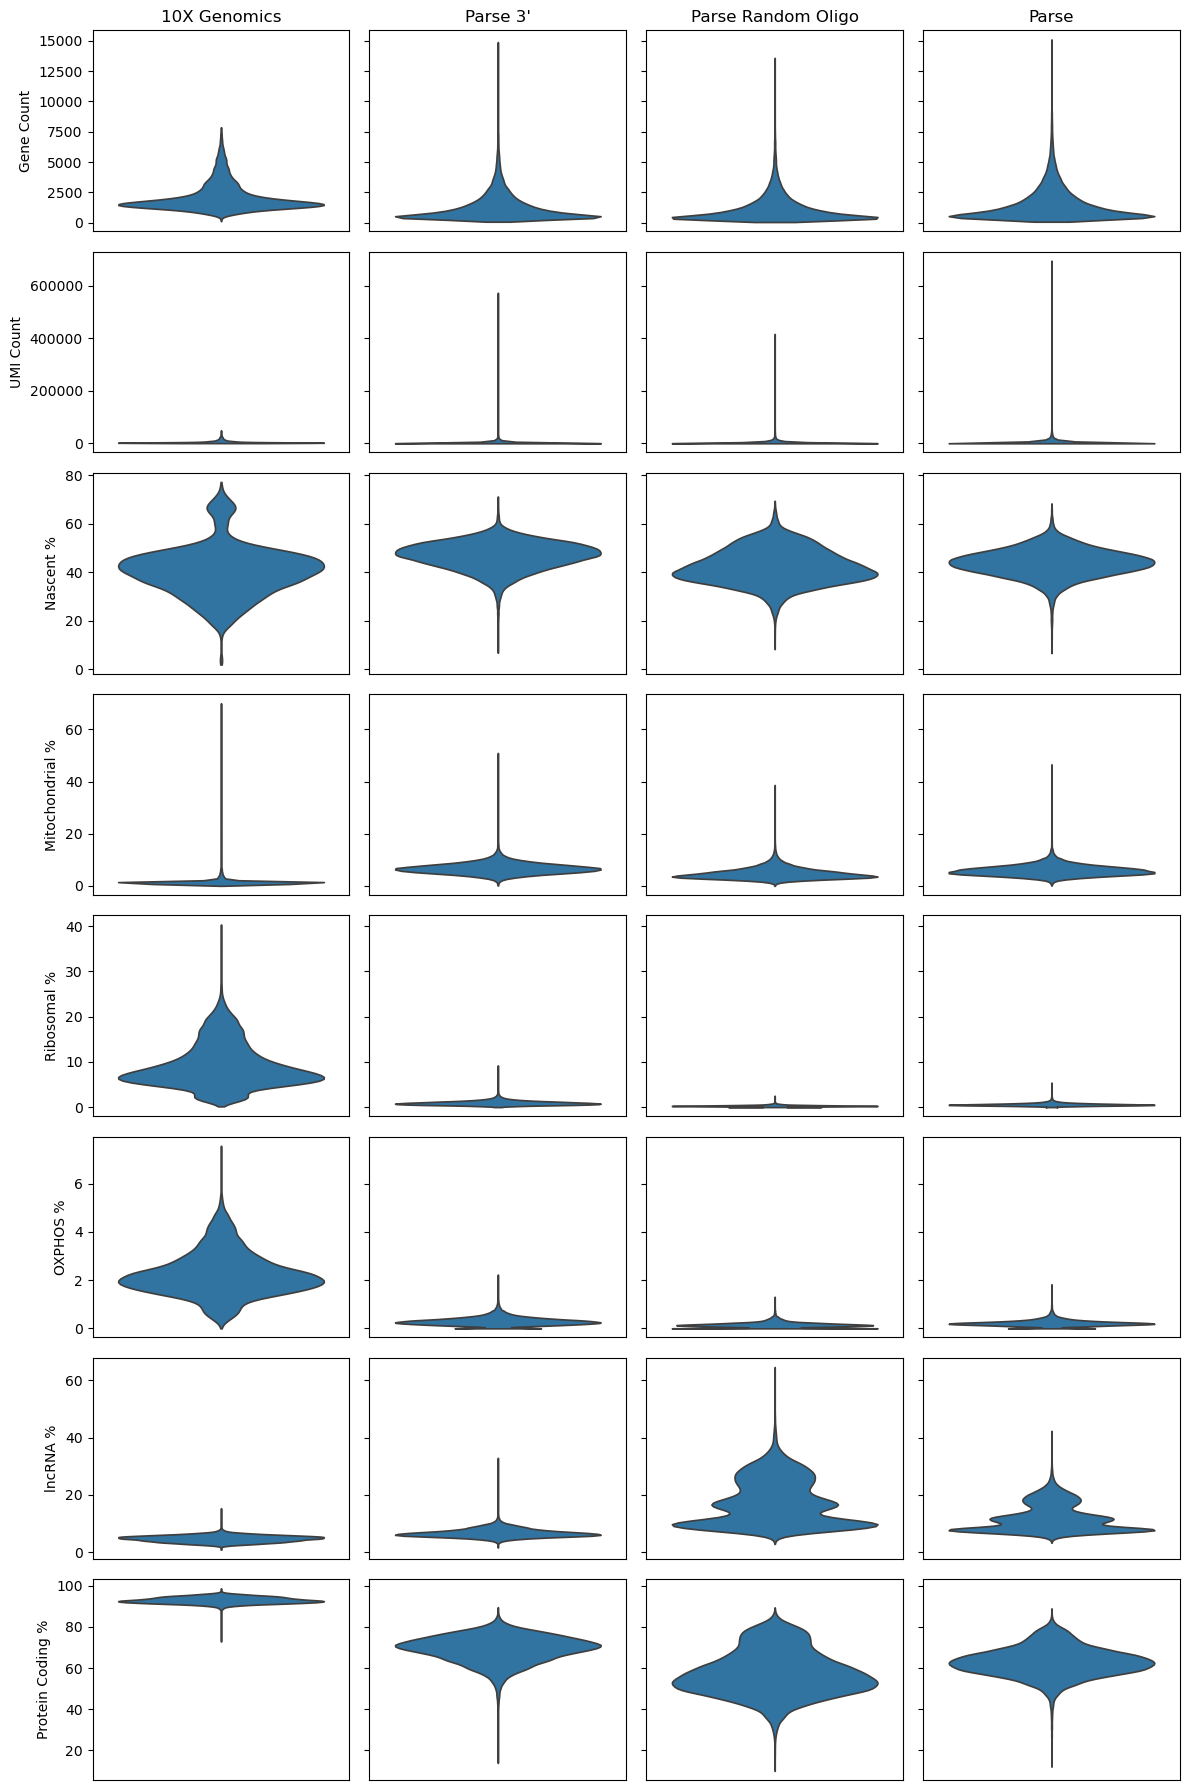

In [16]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_oxphos', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'OXPHOS %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

# Read/Gene Comparisons

In [17]:
# Pan-leukocyte anchor
pan_leukocyte = ["Ptprc"]

# Early thymic progenitor & T-lineage commitment (ETP / DN1–DN2)
early_progenitor_commitment = ["Kit", "Cd44", "Bcl11b", "Tcf7", "Gata3"]

# Rearrangement & β-selection (DN3–DN4)
rearrangement_beta_selection = ["Il2ra", "Rag1", "Rag2", "Ptcra", "Dntt"]

# Proliferation
proliferation = ["Mki67"]

# DP identity & TCR/CD3
dp_identity = ["Cd4", "Cd8a", "Cd8b1", "Cd24a", "Cd3e", "Cd3d", "Cd3g"]

# Positive selection & TCR signal strength
positive_selection_signal = ["Themis", "Cd69", "Cd5", "Cd28", "Nr4a1"]

# CD4 vs CD8 lineage commitment
lineage_commitment = ["Zbtb7b", "Runx3"]

# SP maturation & thymic egress
sp_maturation_egress = ["Ccr9", "Ccr7", "Sell", "Klf2", "S1pr1"]

# Regulatory T cells
treg = ["Foxp3"]

# Survival / negative-selection axis
survival_negative_selection = ["Bcl2", "Bcl2l11"]

# γδ / innate-like lineage
gd_innate = ["Zbtb16"]

# Stromal & myeloid contamination flags (QC) — NOT thymocyte-intrinsic
qc_stromal_myeloid = ["Aire", "Krt5", "Krt8", "Krt18", "Lyz2"] #"Krt14"

thymocyte_markers = {
    "Pan Leukocyte": pan_leukocyte,
    "Early Progenitor Commitment": early_progenitor_commitment,
    "Rearrangement/Beta Selection": rearrangement_beta_selection,
    "Proliferation": proliferation,
    "DP Identity": dp_identity,
    "Positive Selection Signal": positive_selection_signal,
    "Lineage Commitment": lineage_commitment,
    "SP Maturation Egress": sp_maturation_egress,
    "Treg": treg,
    "Survival Negative Selection": survival_negative_selection,
    "GD Innate": gd_innate,
    "Stromal/Myeloid QC": qc_stromal_myeloid,
}

# TCR loci — PREFIXES (match by startswith, not exact)
tcr_loci_prefixes = ["Trav", "Trbv", "Trgv", "Trdv"]

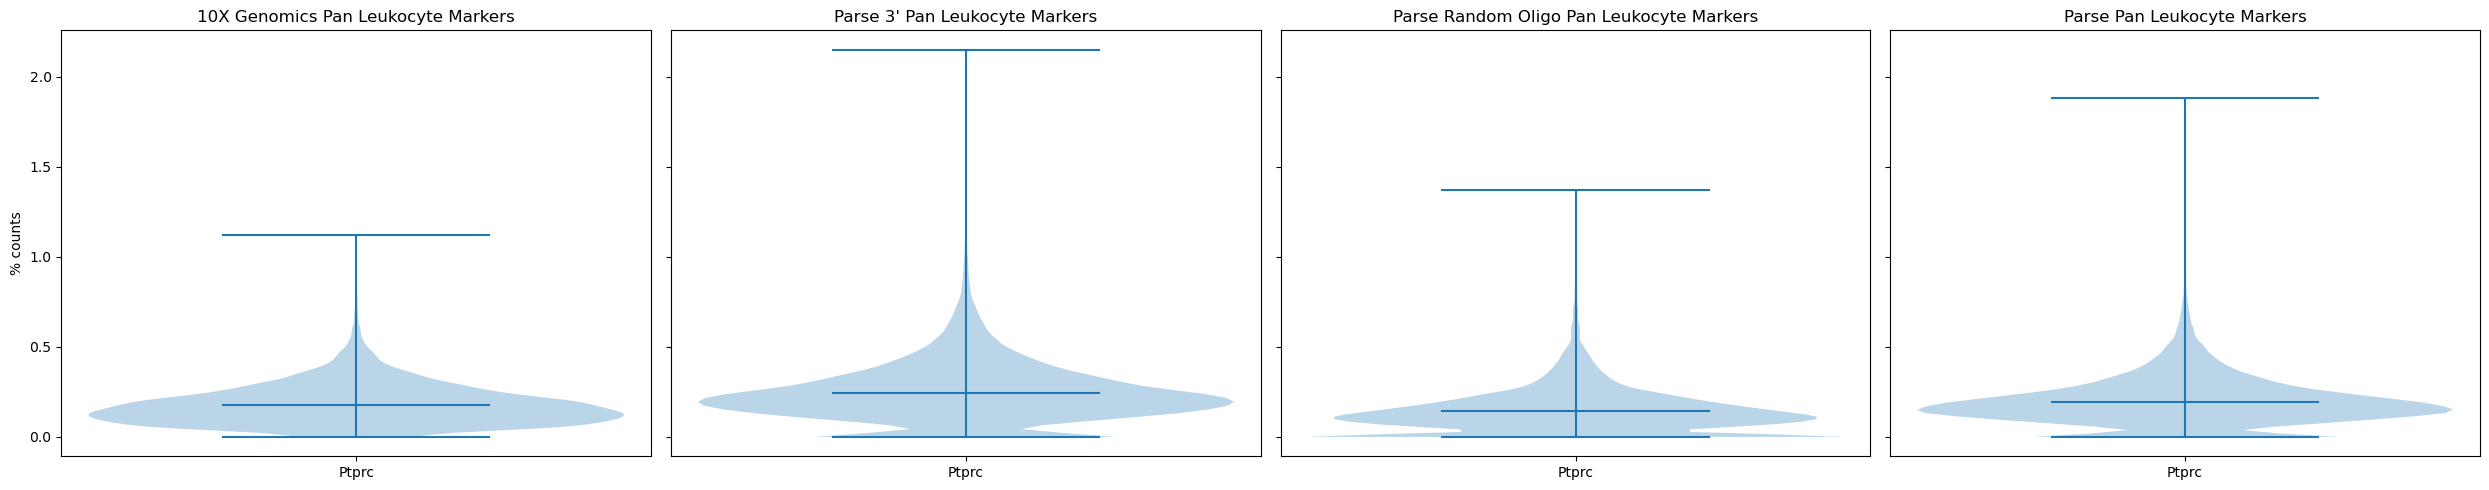

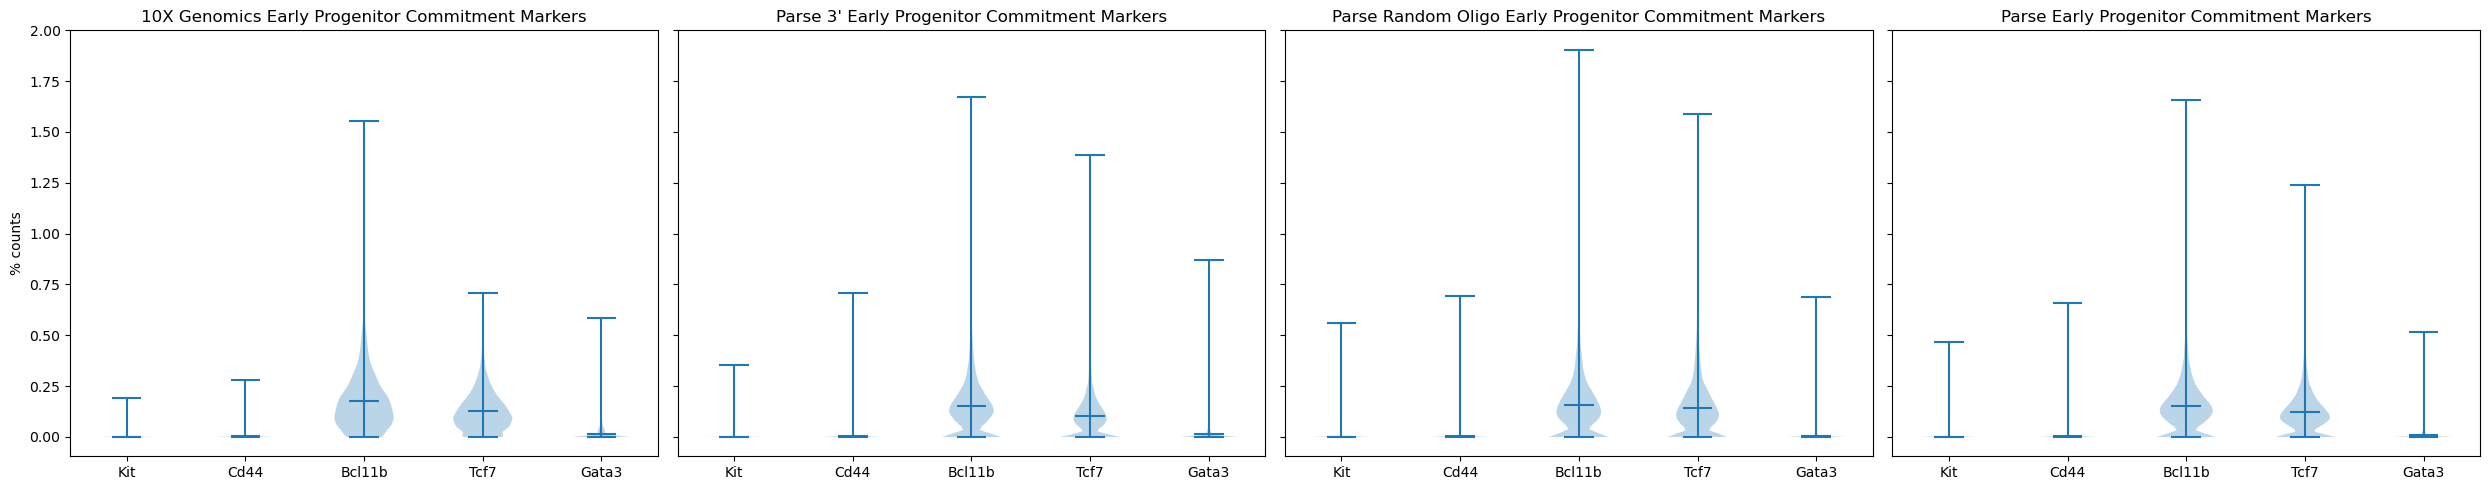

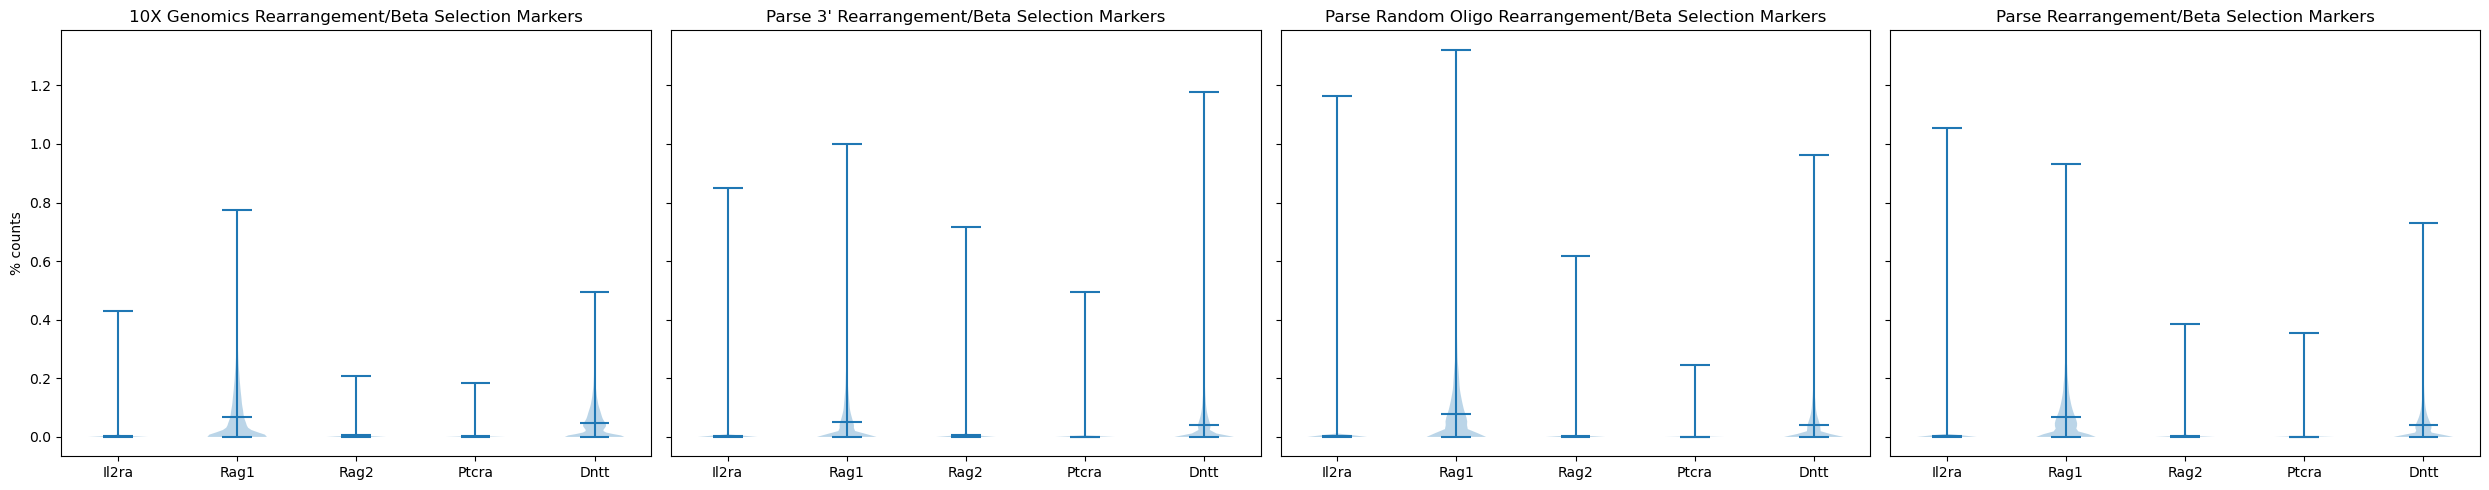

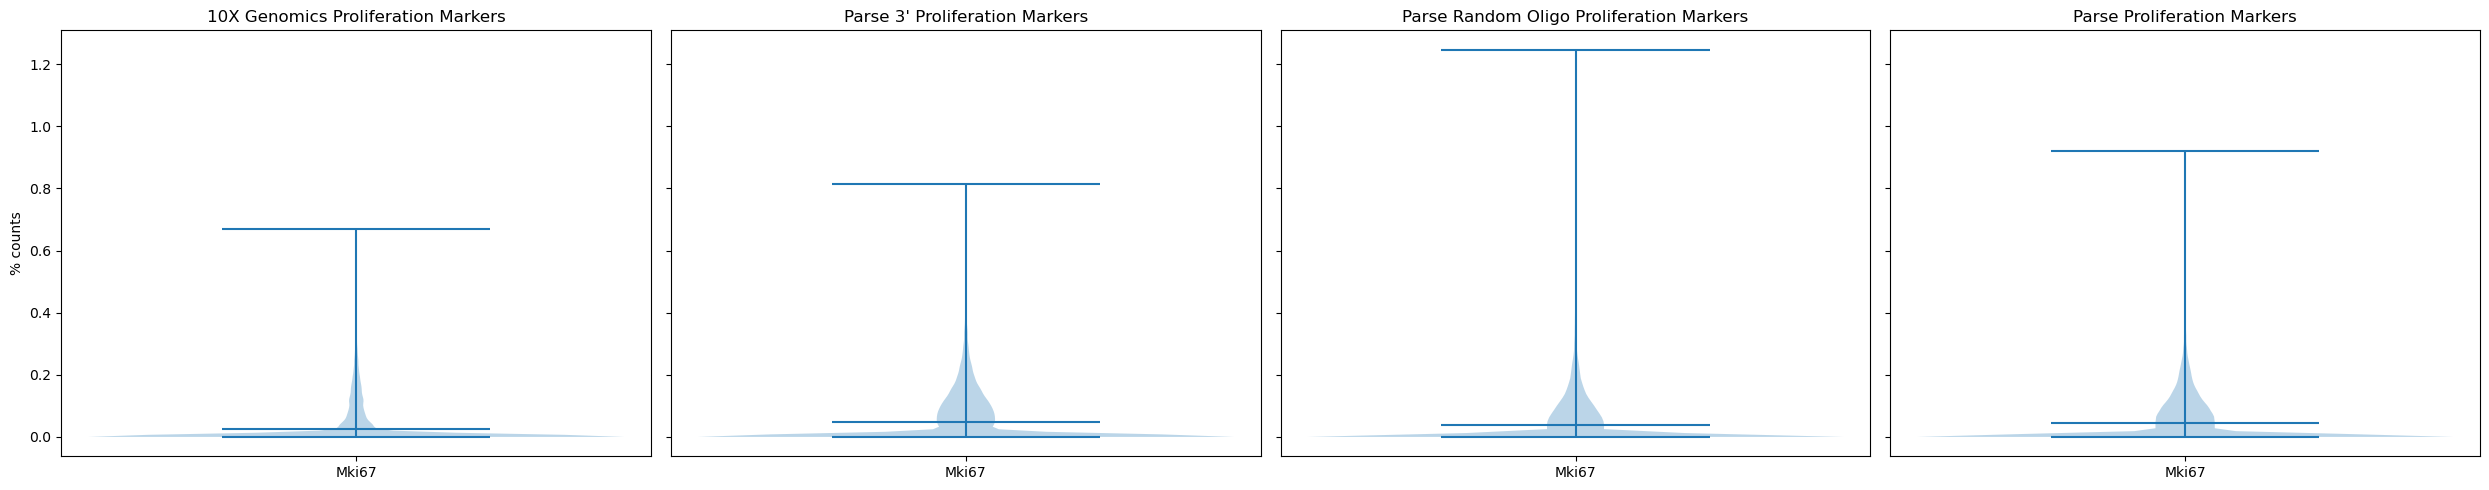

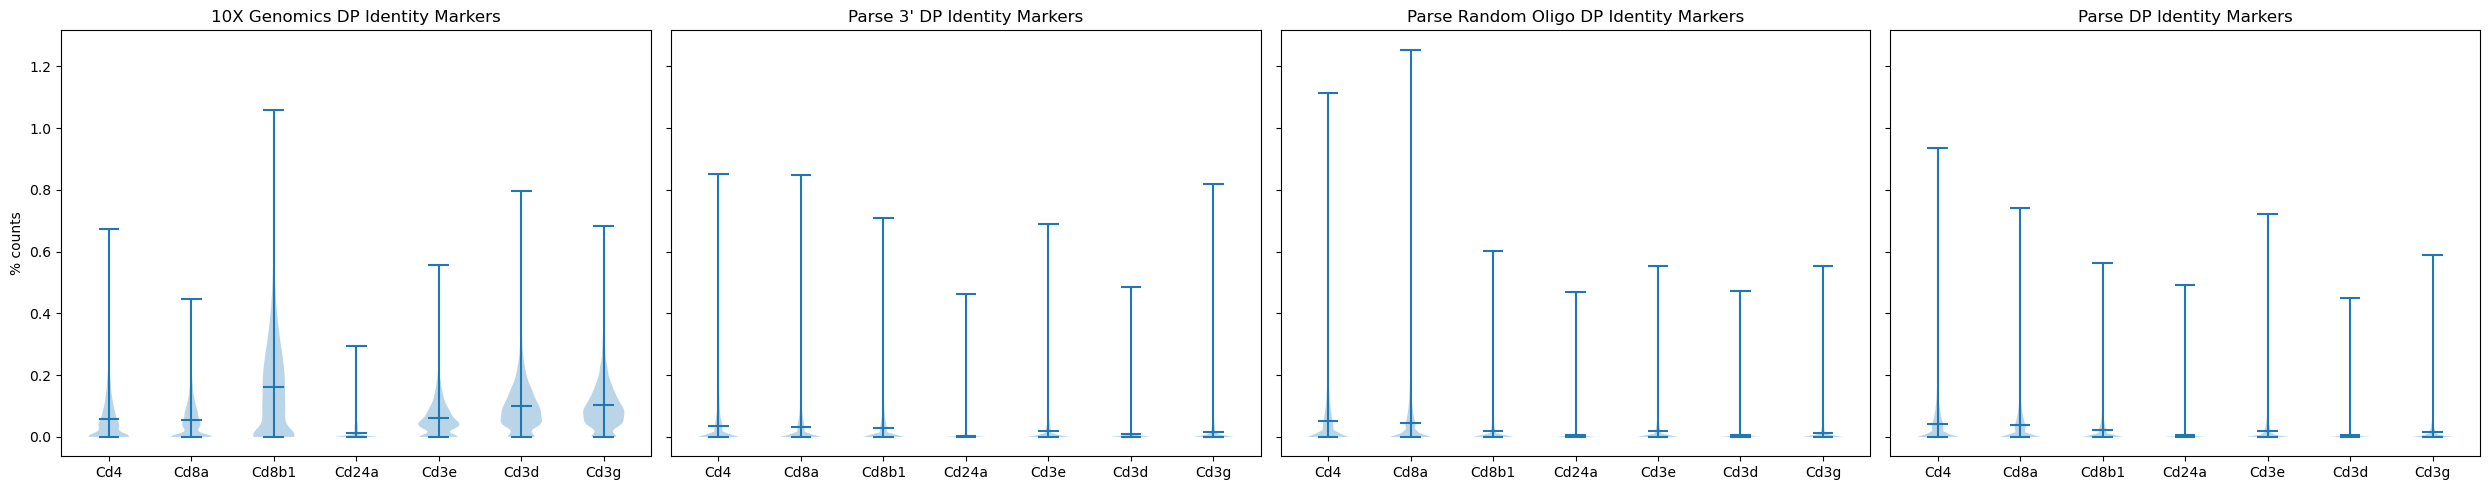

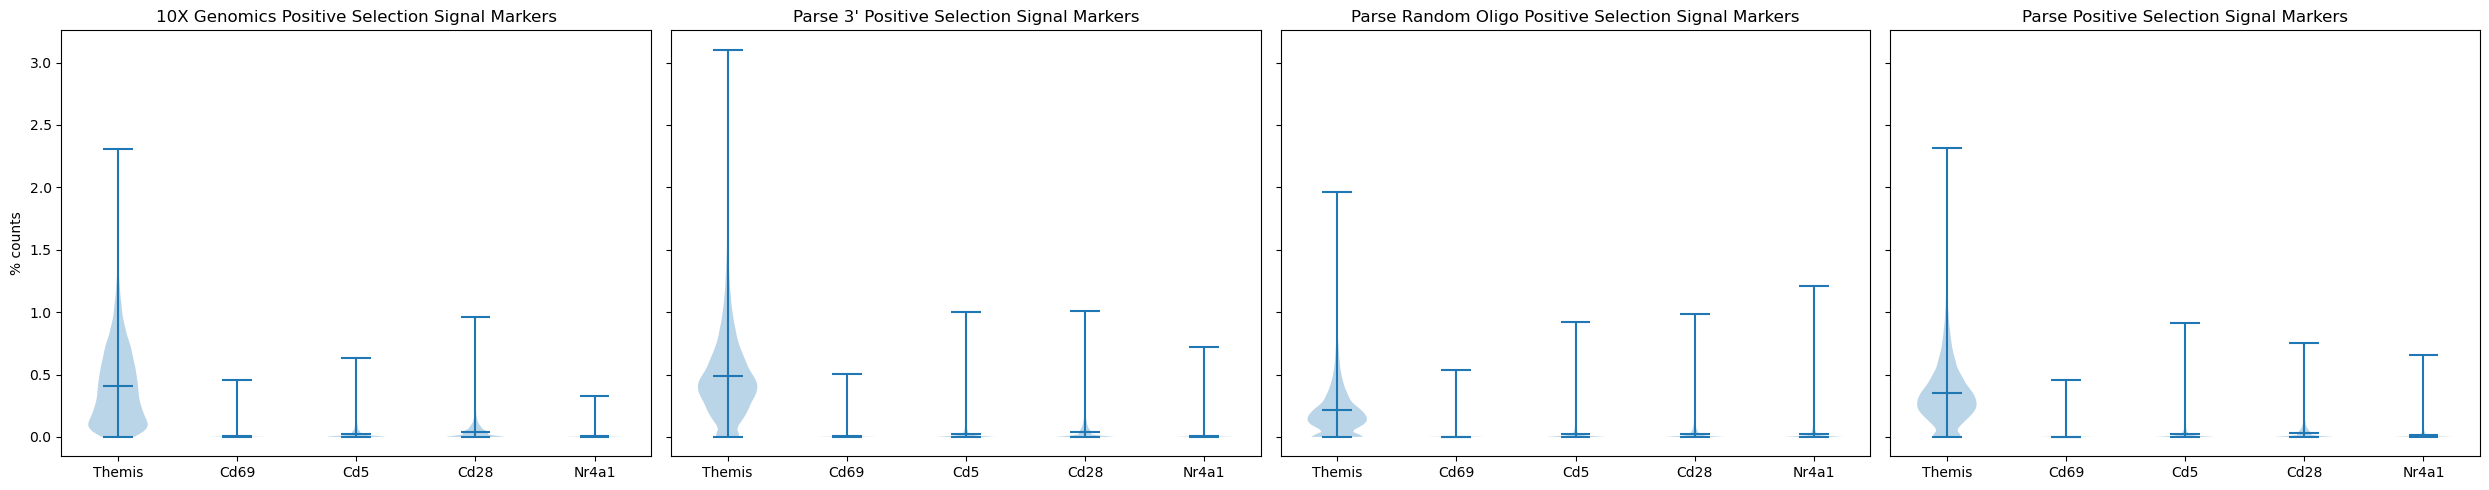

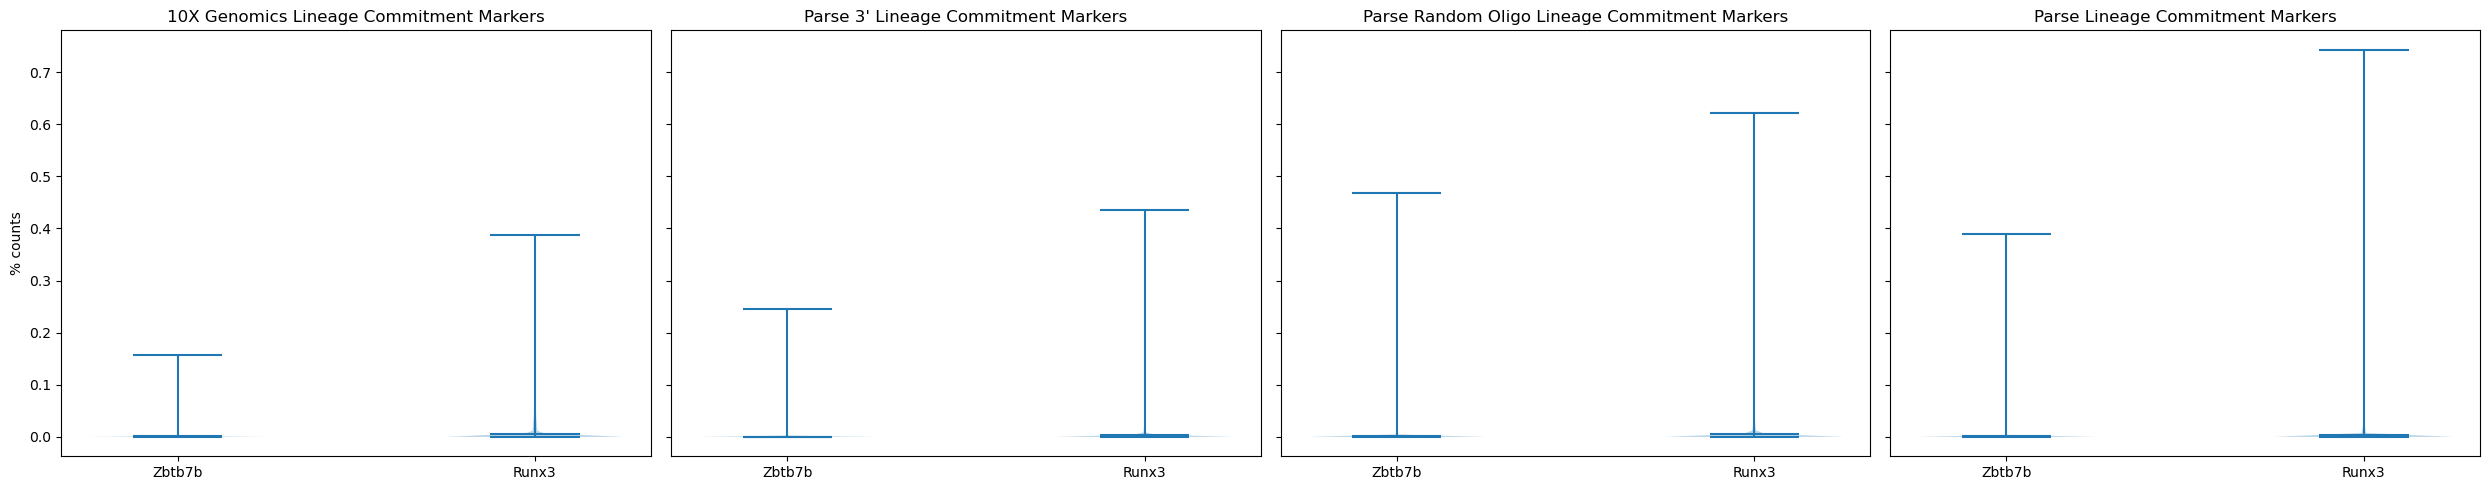

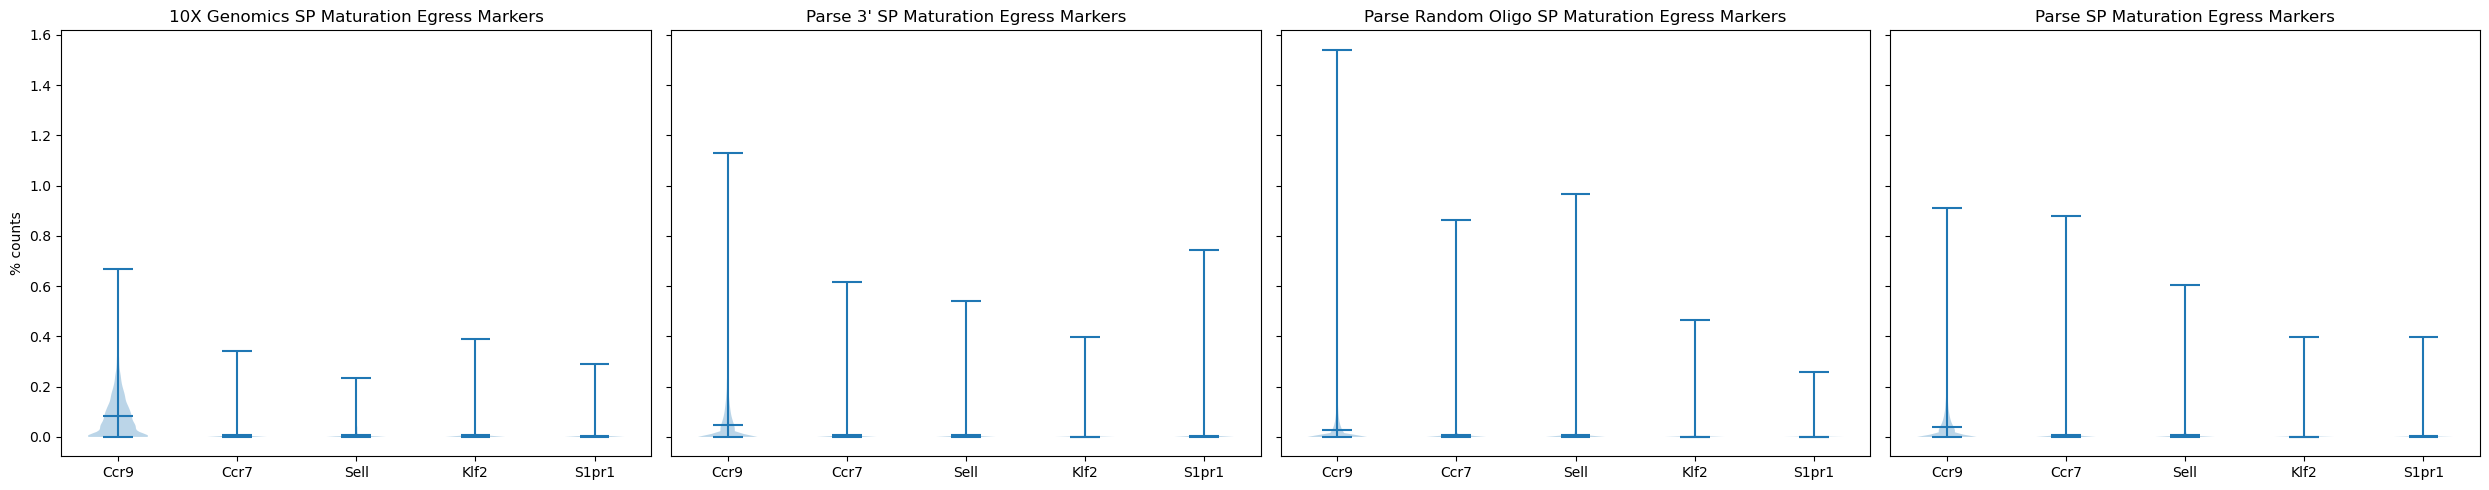

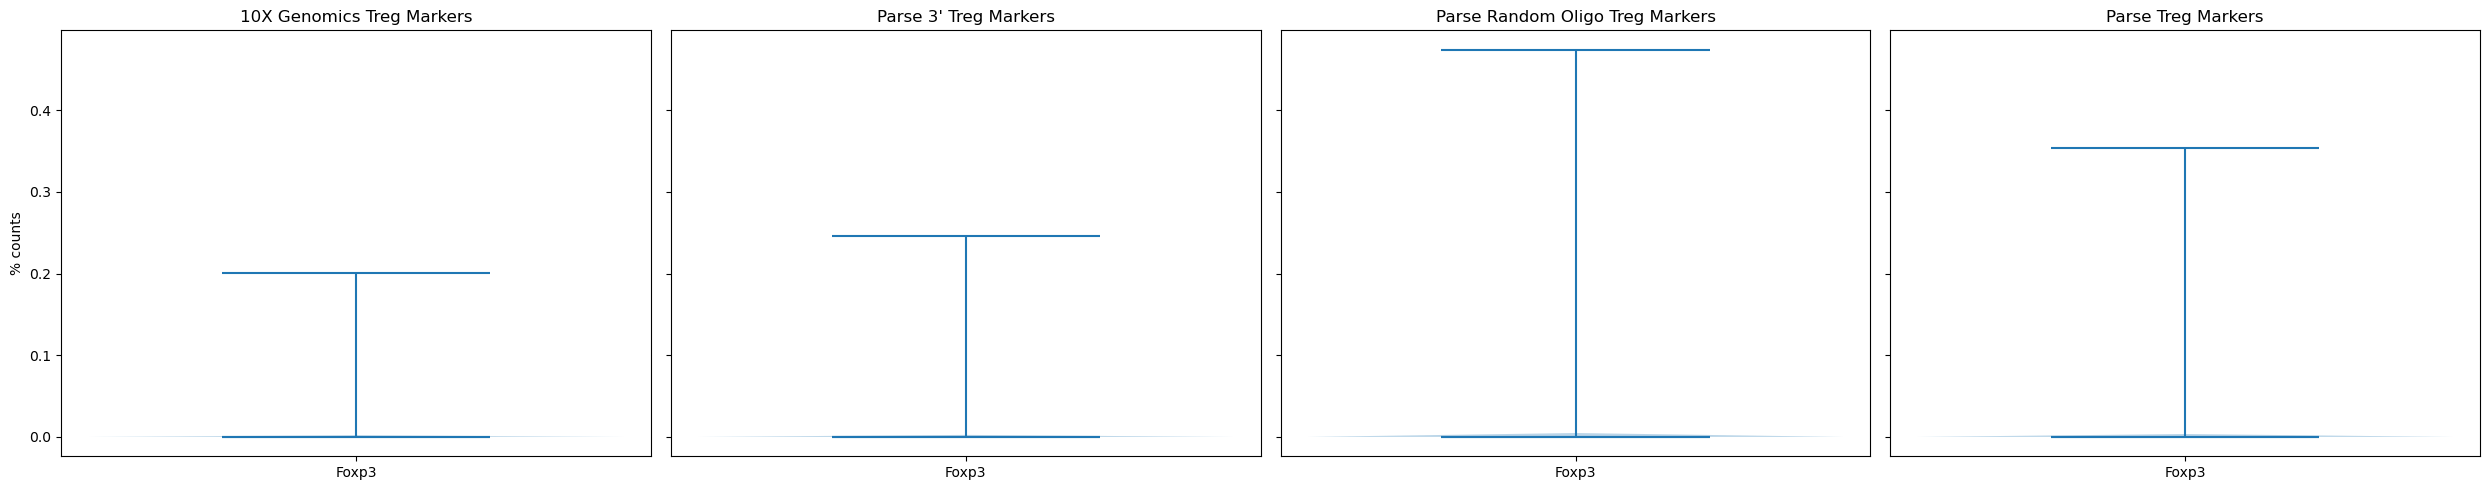

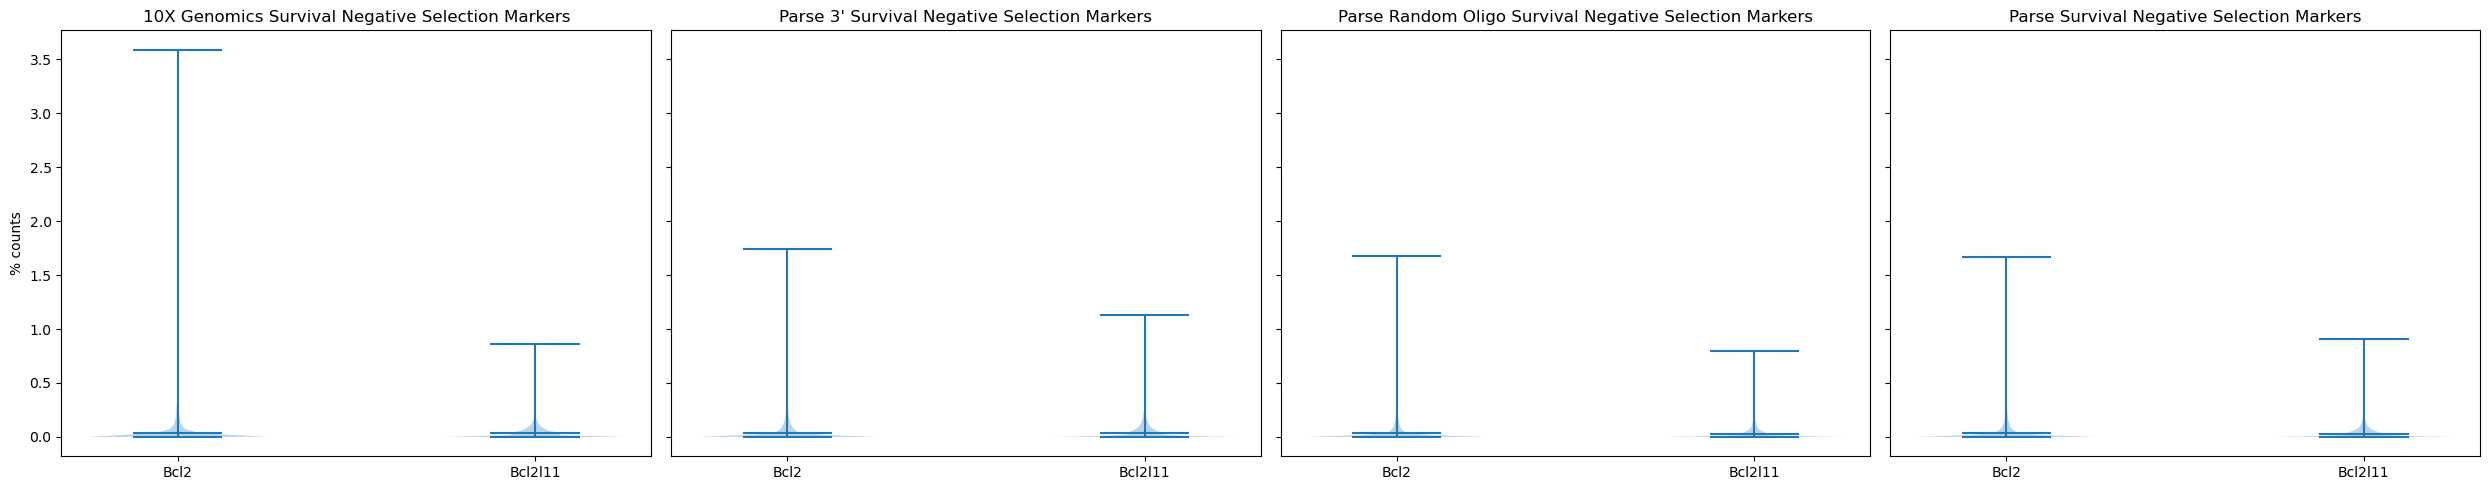

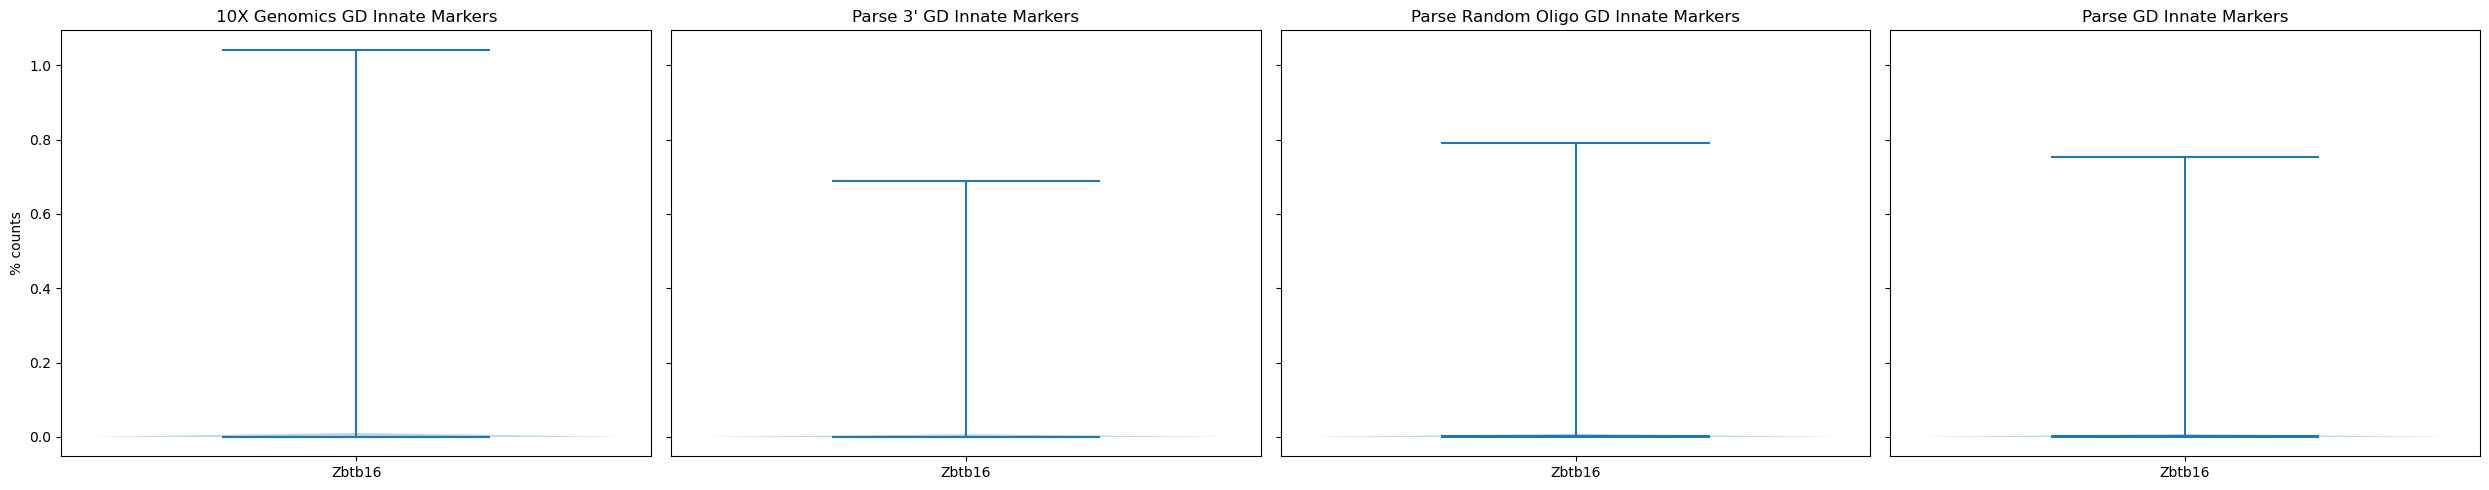

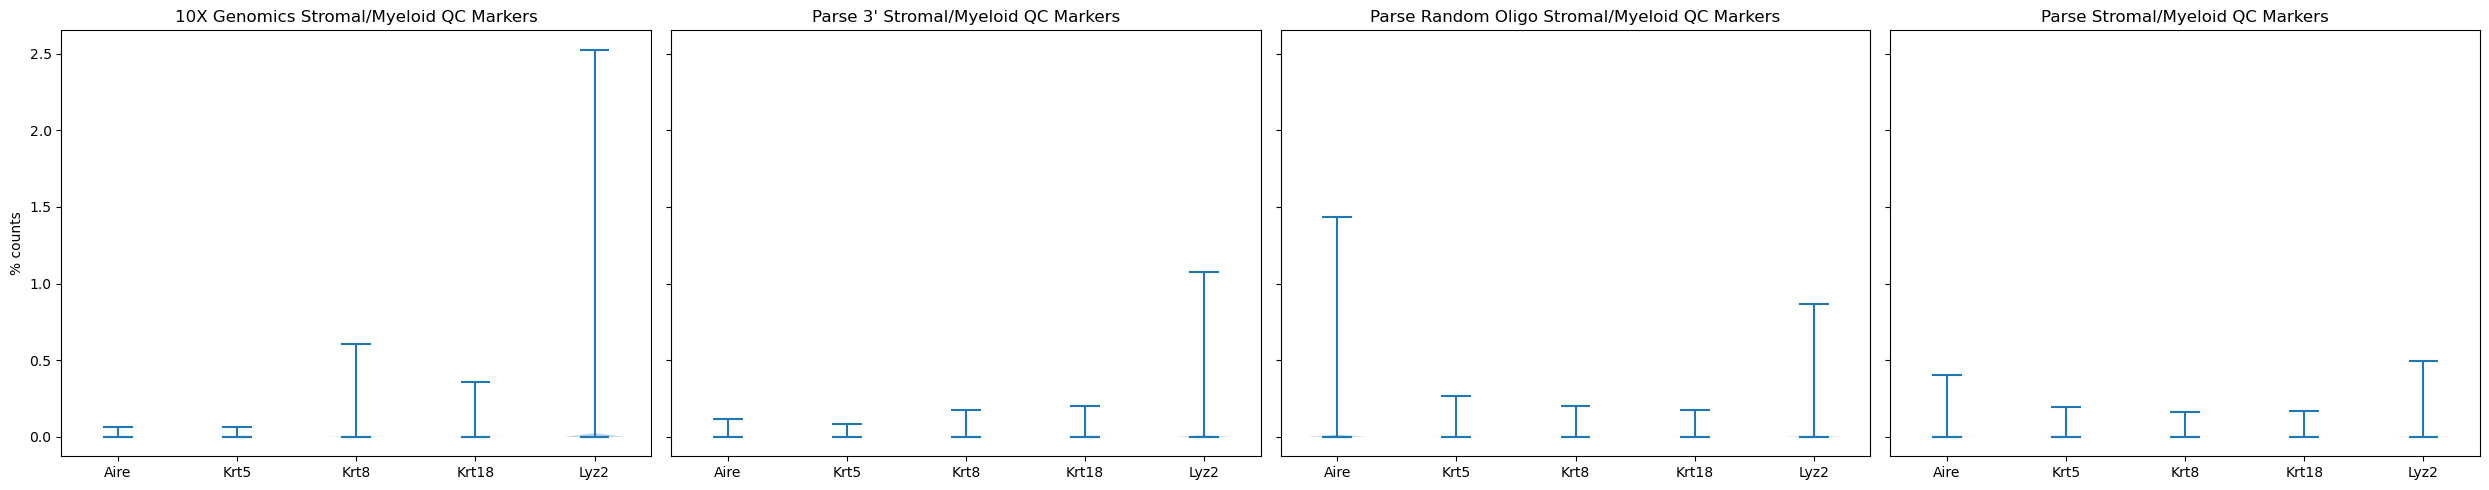

In [18]:
for marker_set_name in thymocyte_markers.keys():
    plotting.marker_genes(datasets, thymocyte_markers[marker_set_name], plot_title=marker_set_name + " Markers")

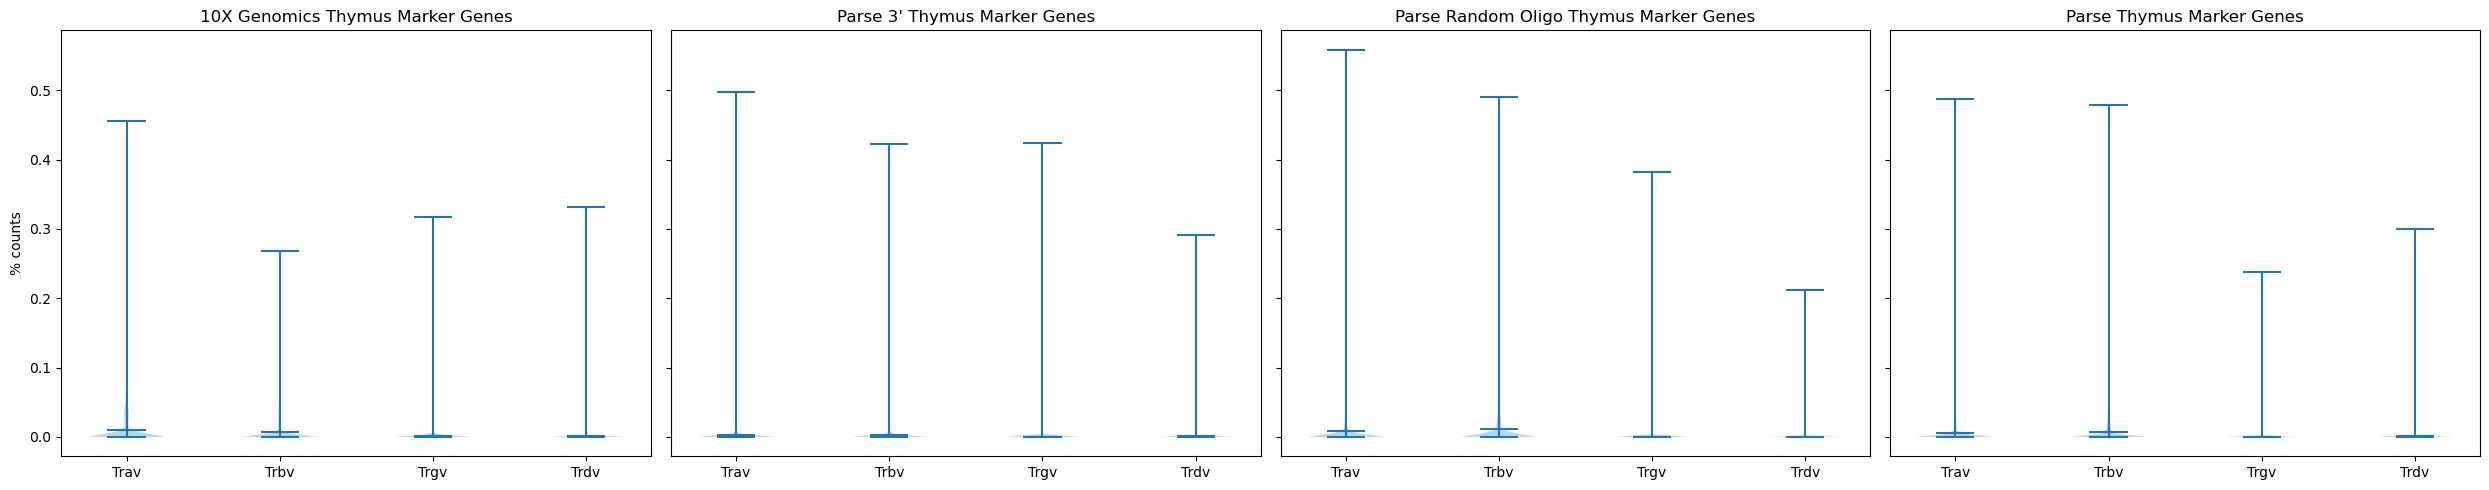

In [19]:
plotting.collapsed_marker_genes(datasets, tcr_loci_prefixes)

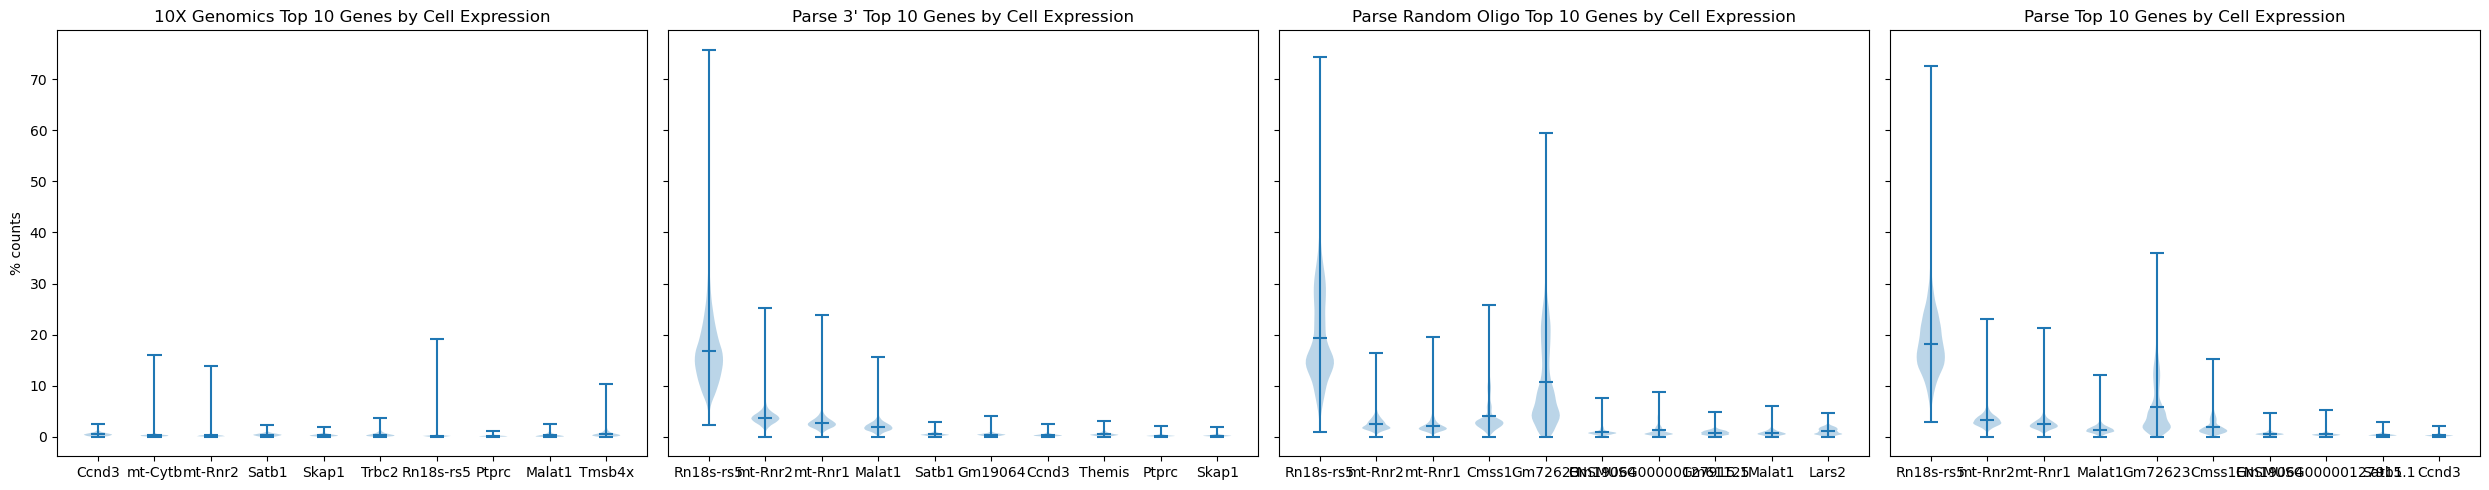

In [20]:
plotting.top_gene_cell_expression(datasets)

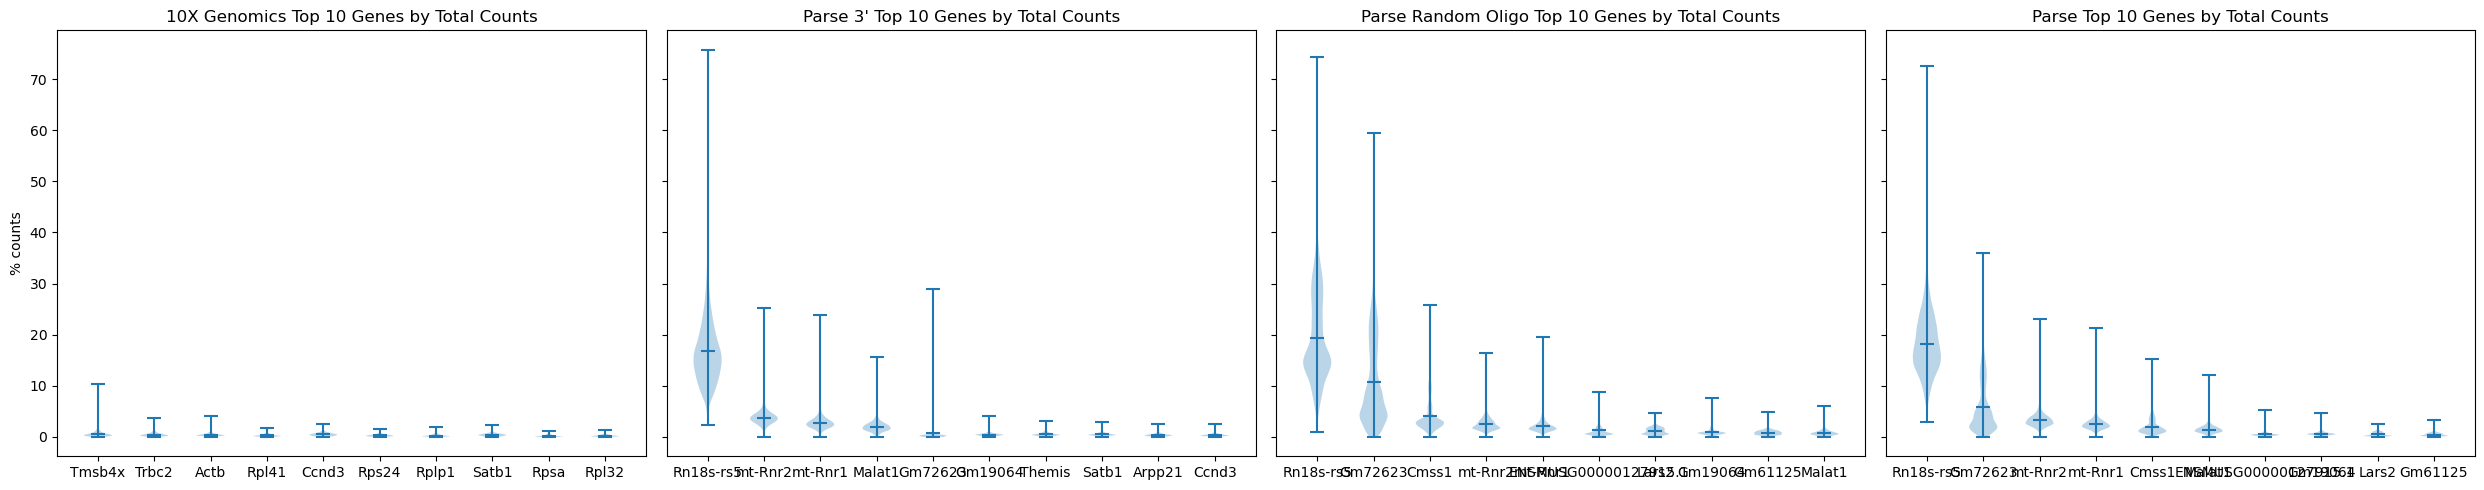

In [21]:
plotting.top_gene_counts(datasets)

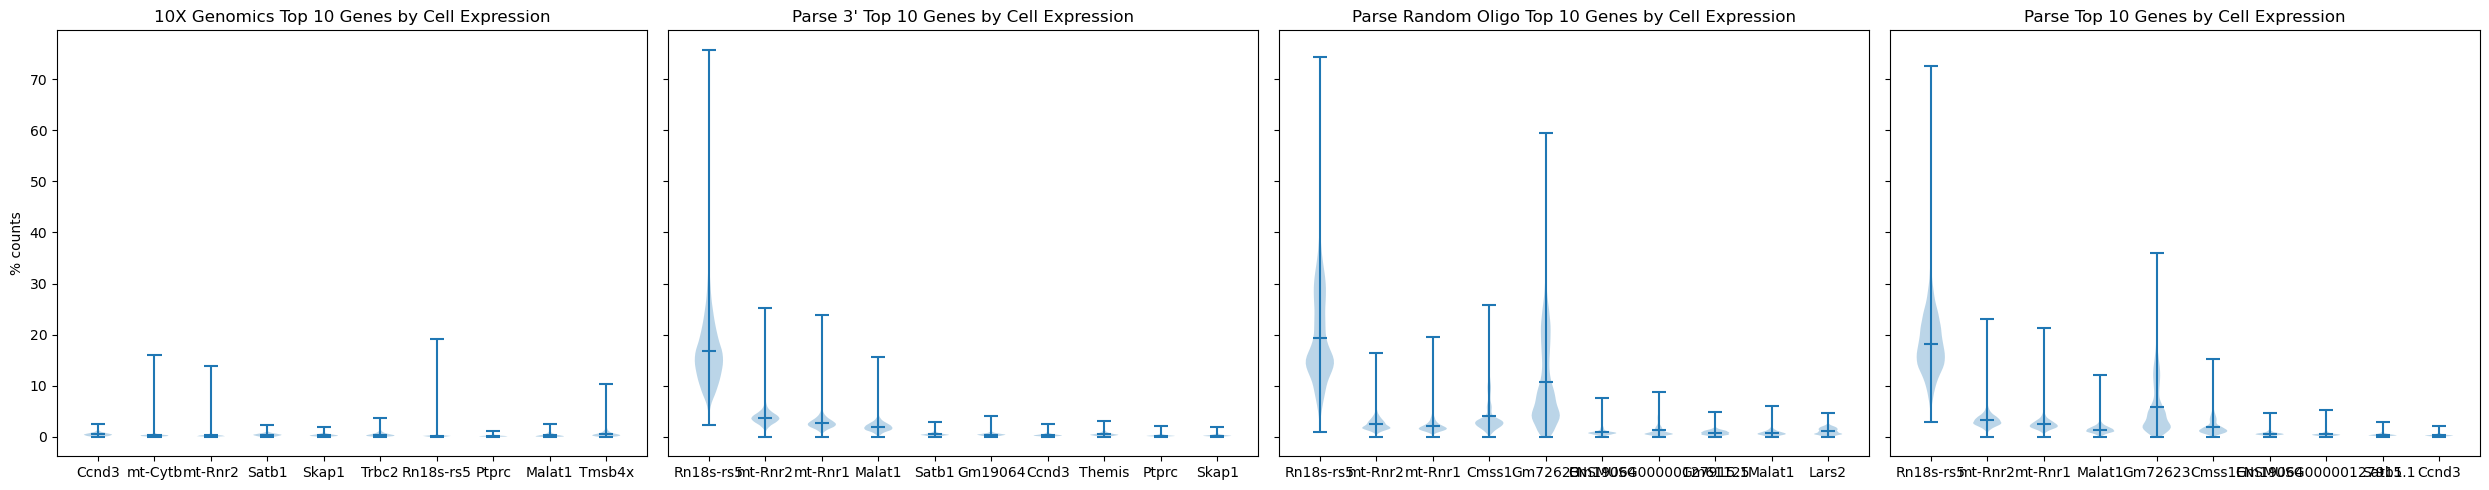

In [22]:
plotting.top_gene_cell_expression(datasets)

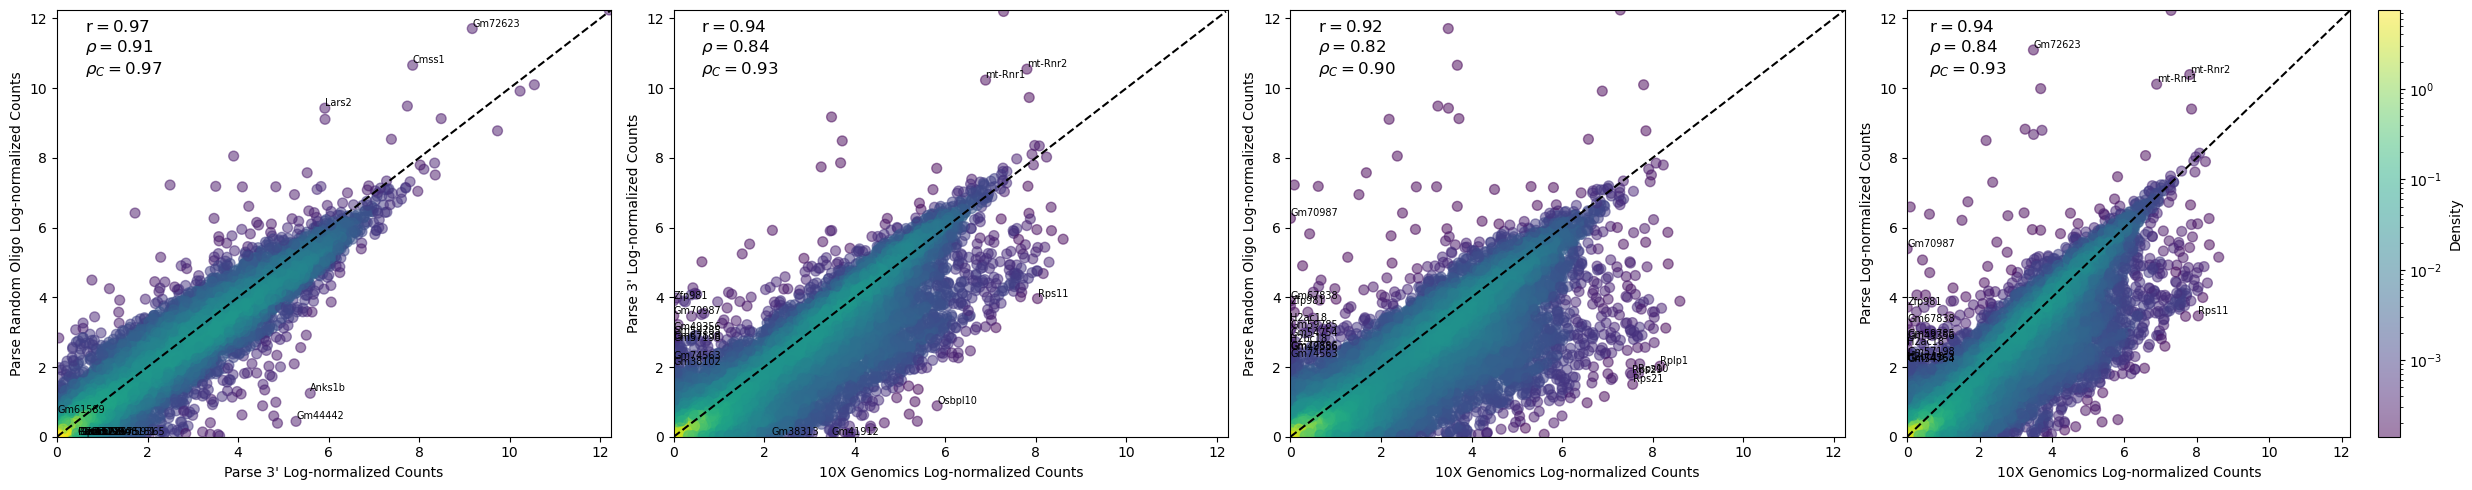

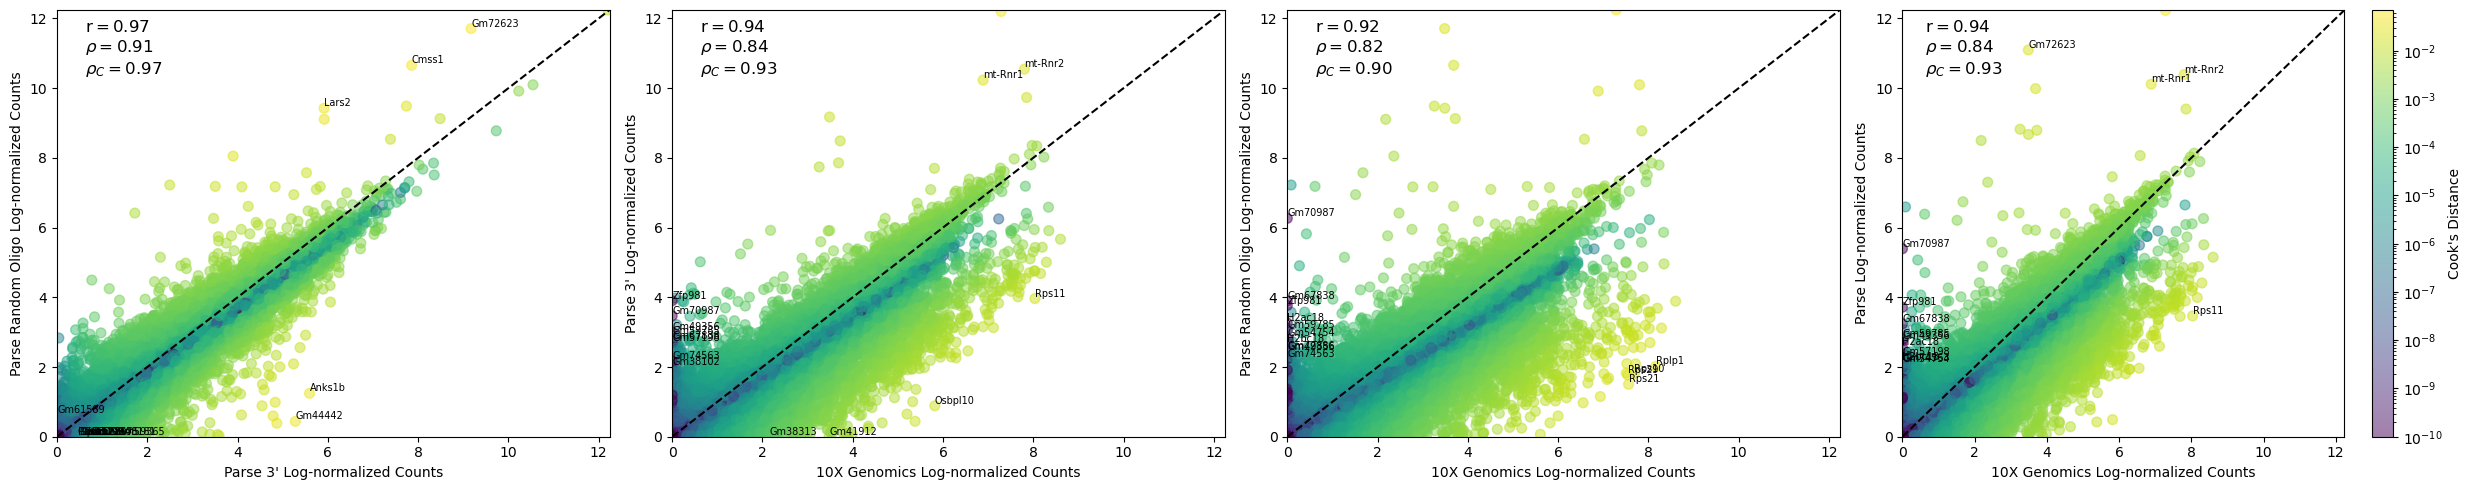

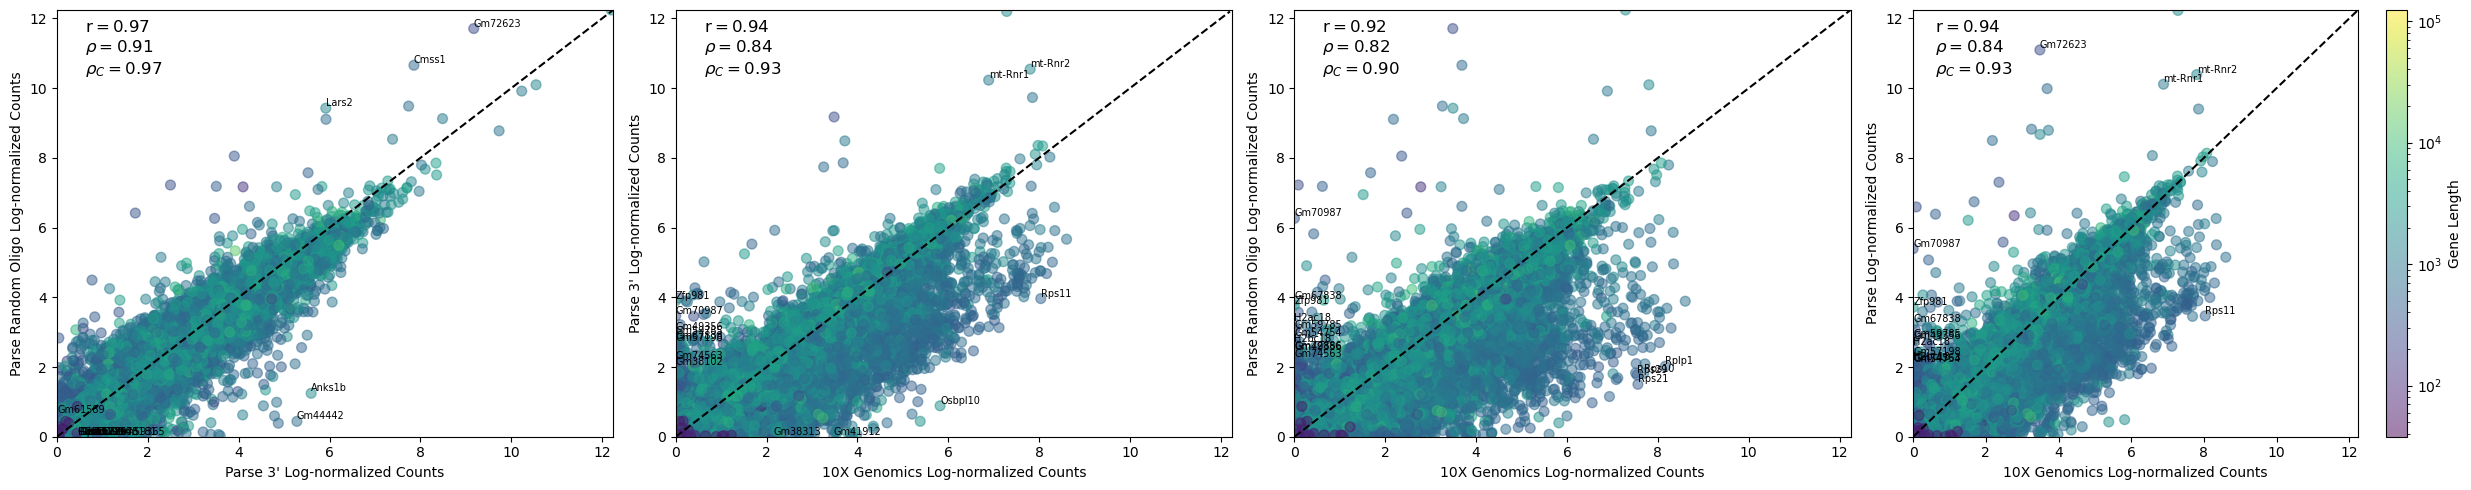

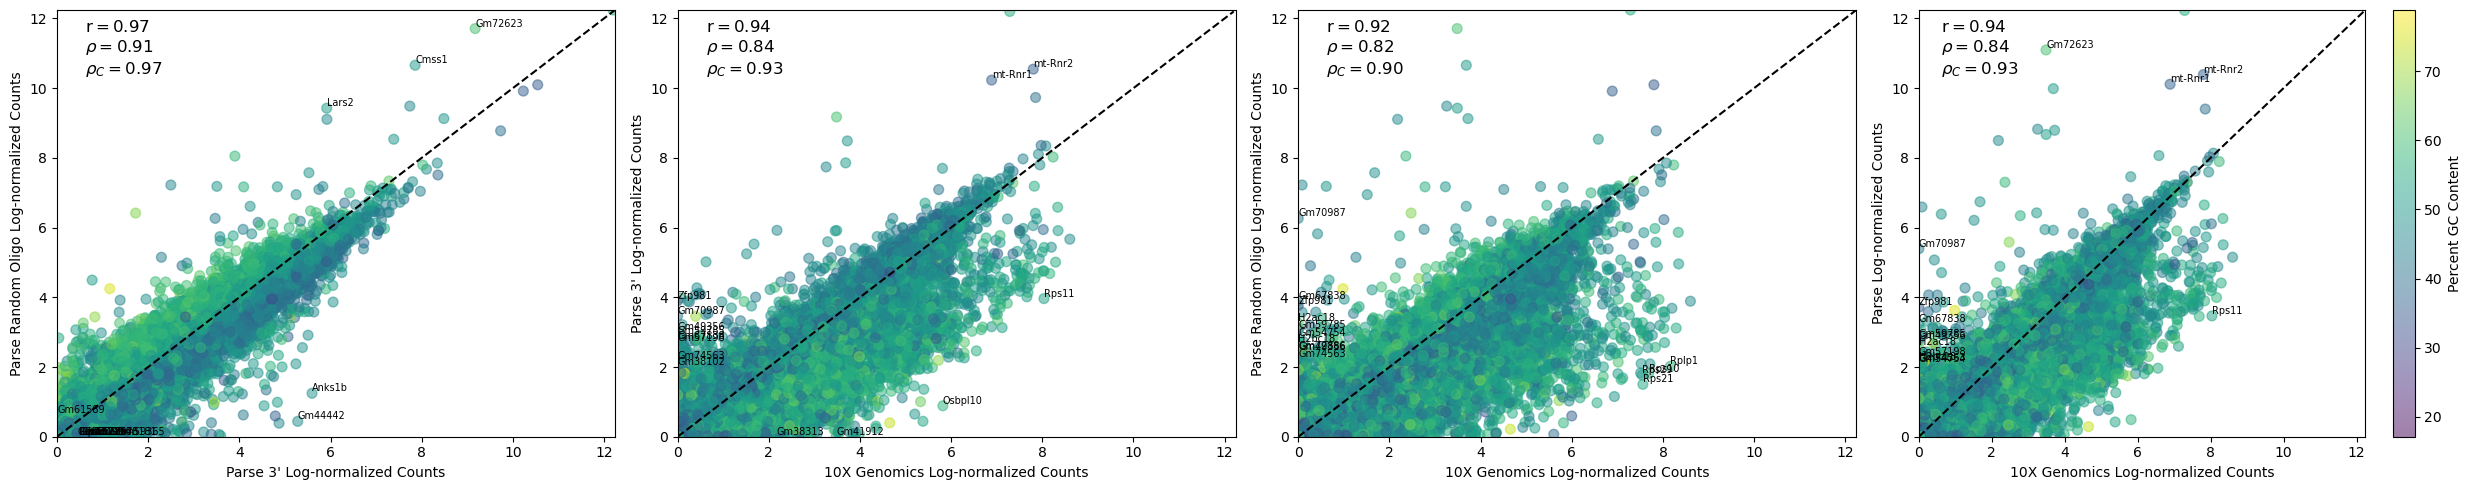

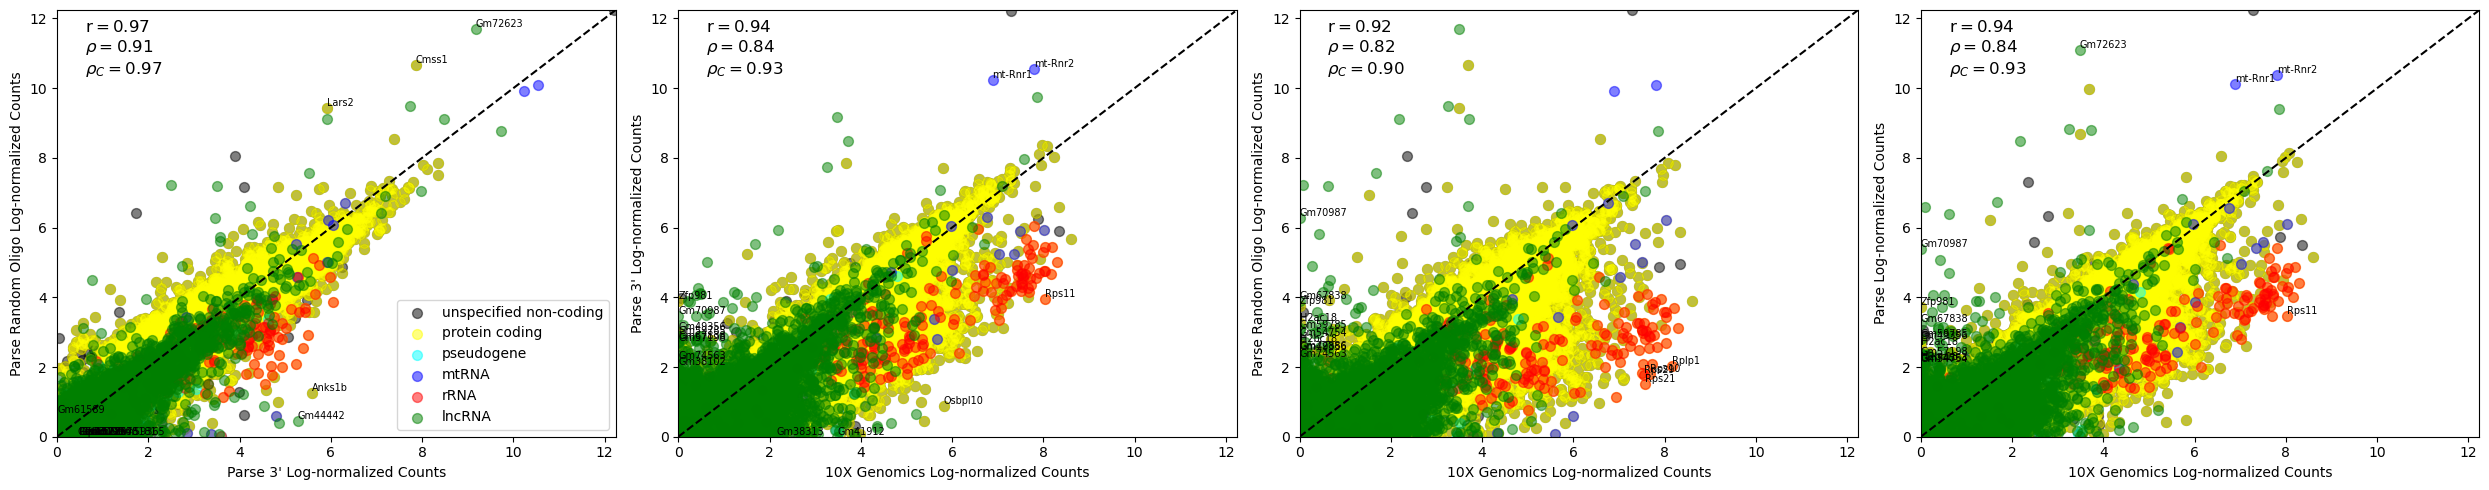

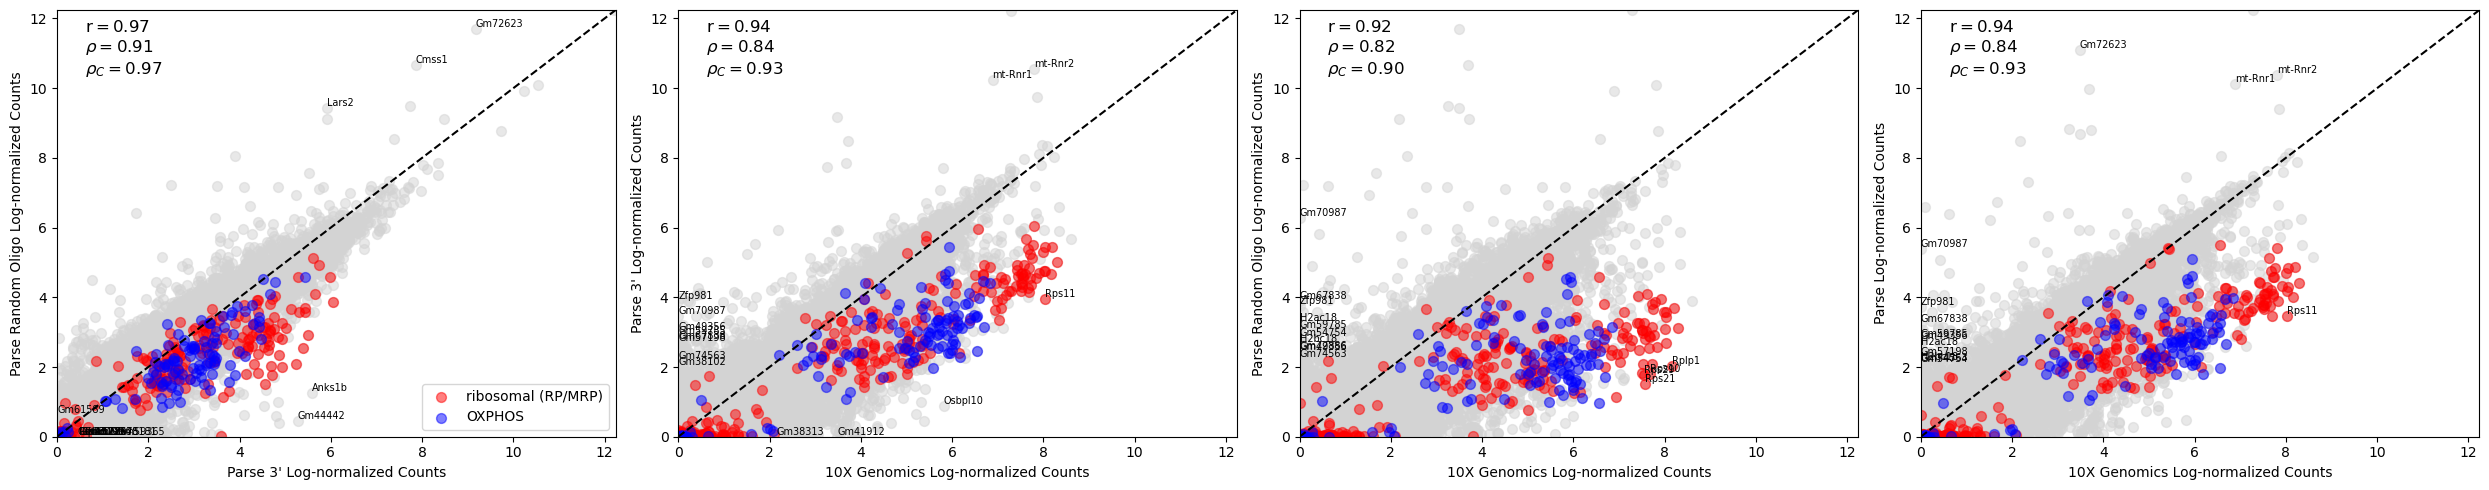

In [23]:

compare_names, compare_dfs = plotting.compare(datasets)

In [24]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

/home/mcaskey/10XvParse/XvP_utils/processing.py:340: UserWarning: compare_by_enrichment: 1 genes in "Mouse Housekeeping Genes" but missing from data:
  ['']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mouse Housekeeping Genes: 815/1150 toward Parse 3', 335/1150 toward Parse Random Oligo, p=1.84e-13
  10X Genomics vs Parse 3' | Mouse Housekeeping Genes: 873/1153 toward 10X Genomics, 280/1153 toward Parse 3', p=4.65e-13
  10X Genomics vs Parse Random Oligo | Mouse Housekeeping Genes: 938/1154 toward 10X Genomics, 216/1154 toward Parse Random Oligo, p=2.96e-18
  10X Genomics vs Parse | Mouse Housekeeping Genes: 923/1154 toward 10X Genomics, 231/1154 toward Parse, p=2.71e-18


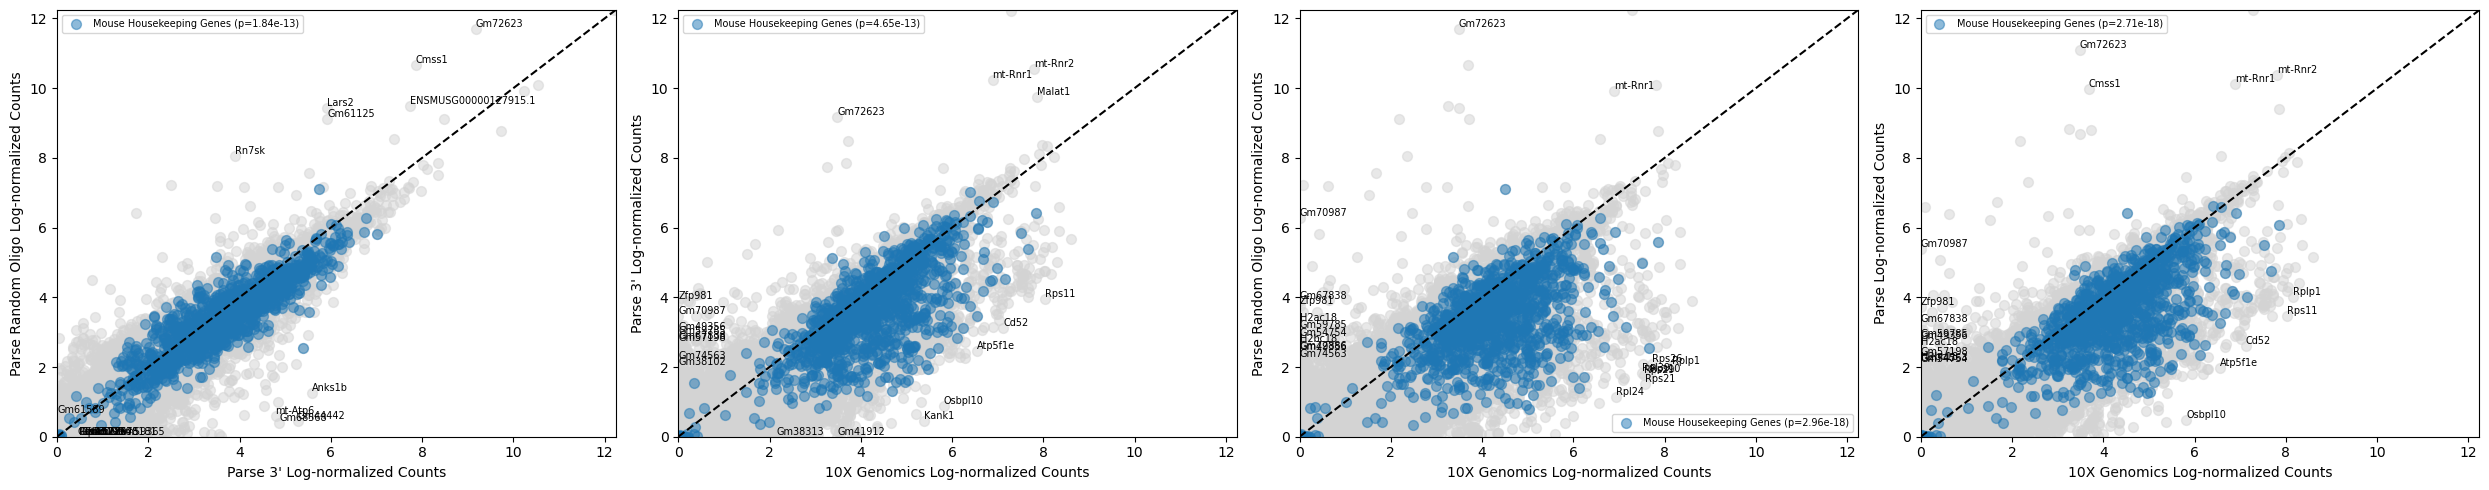

In [25]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path=str(PROJECT_DIR / "Notebooks/important_gene_sets.csv"),
    gene_sets=["Housekeeping"],
    terms=["Mouse Housekeeping Genes"])

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=6346): 2278/4105 (55.49%) toward Parse 3', 1827/4105 (44.51%) toward Parse Random Oligo, p=4.82e-34
  Parse 3' vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=5418): 2354/3114 (75.59%) toward Parse 3', 760/3114 (24.41%) toward Parse Random Oligo, p=1.00e-61
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=6346): 3635/4109 (88.46%) toward 10X Genomics, 474/4109 (11.54%) toward Parse 3', p=8.06e-289
  10X Genomics vs Parse 3' | Higher in Parse 3' Human PBCMS (n=5418): 1196/3111 (38.44%) toward 10X Genomics, 1915/3111 (61.56%) toward Parse 3', p=2.24e-318
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=6346): 3367/4114 (81.84%) toward 10X Genomics, 747/4114 (18.16%) toward Parse Random Oligo, p=5.92e-50
  10X Genomics vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=5418): 2024/3109 (65.10%) toward 10X Genomics, 1085/3109 (34.90%) toward Parse Random O

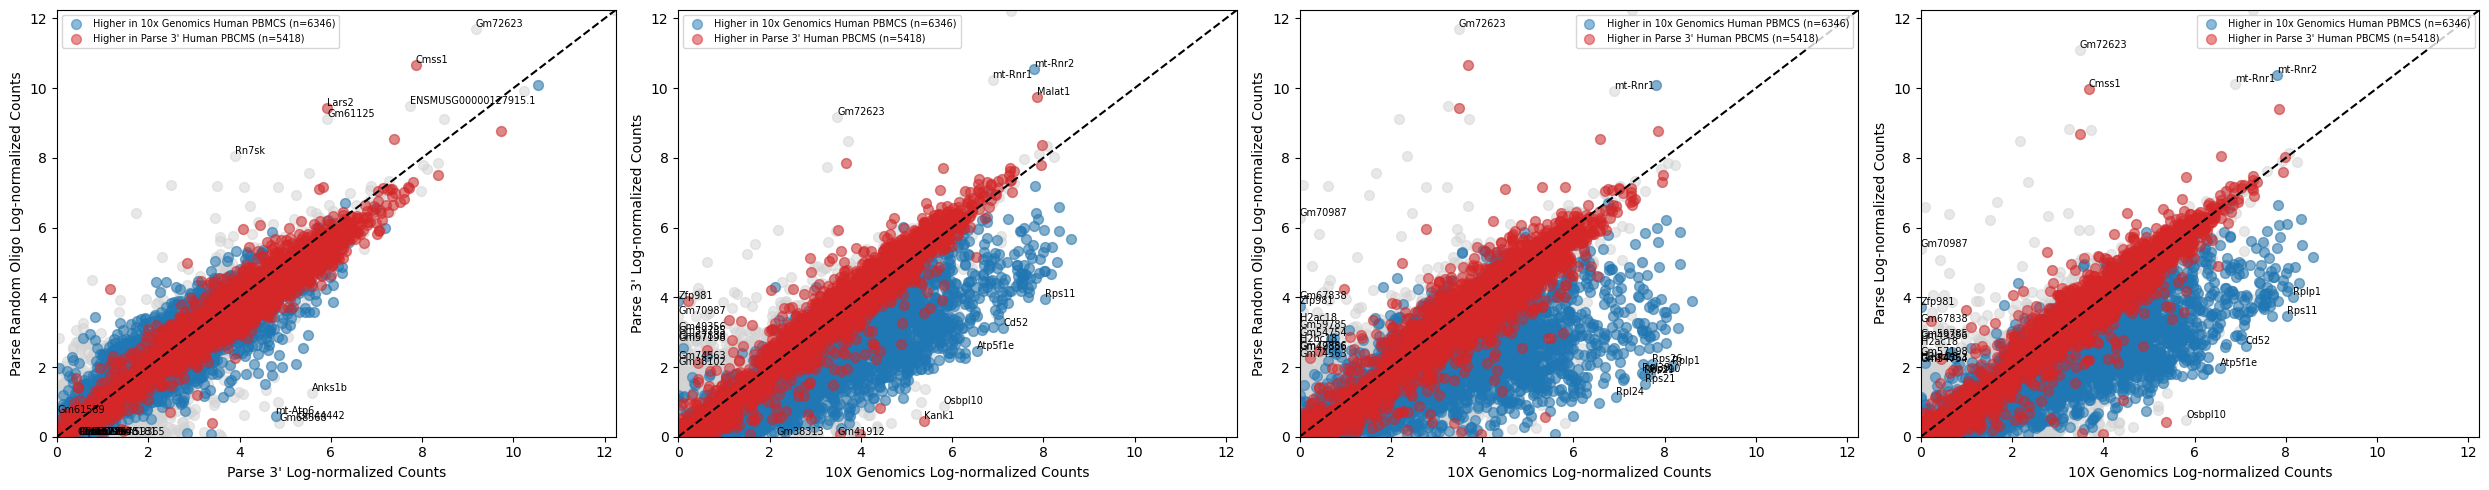

In [26]:
results= pd.read_csv(str(PROJECT_DIR / "Notebooks/Comparisons/10XvPolyT/results.csv"))

plotting.compare_by_de(
    compare_dfs, comparisons,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse 3' Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=6026): 2346/3669 (63.94%) toward Parse 3', 1323/3669 (36.06%) toward Parse Random Oligo, p=1.83e-01
  Parse 3' vs Parse Random Oligo | Higher in Parse Human PBCMS (n=5399): 1998/3170 (63.03%) toward Parse 3', 1172/3170 (36.97%) toward Parse Random Oligo, p=1.00e+00
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=6026): 3296/3676 (89.66%) toward 10X Genomics, 380/3676 (10.34%) toward Parse 3', p=2.82e-280
  10X Genomics vs Parse 3' | Higher in Parse Human PBCMS (n=5399): 1373/3167 (43.35%) toward 10X Genomics, 1794/3167 (56.65%) toward Parse 3', p=1.15e-226
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=6026): 3238/3676 (88.08%) toward 10X Genomics, 438/3676 (11.92%) toward Parse Random Oligo, p=3.75e-137
  10X Genomics vs Parse Random Oligo | Higher in Parse Human PBCMS (n=5399): 1807/3165 (57.09%) toward 10X Genomics, 1358/3165 (42.91%) toward Parse Random Oligo, p

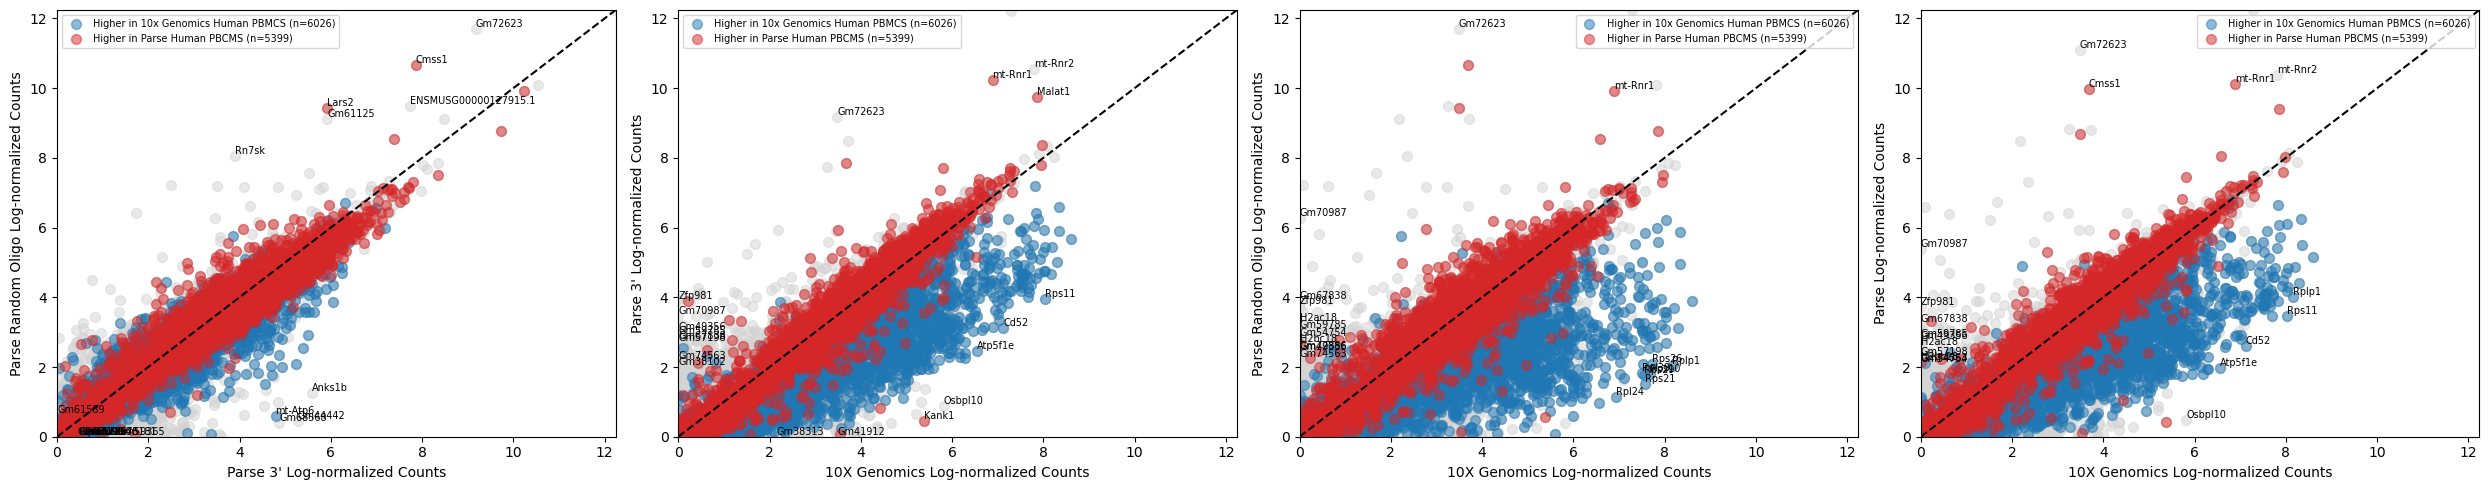

In [27]:
results= pd.read_csv(str(PROJECT_DIR / "Notebooks/Comparisons/10XvParse/results.csv"))

plotting.compare_by_de(
    compare_dfs, comparisons,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

  Parse 3' vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=3984): 2532/2713 (93.33%) toward Parse 3', 181/2713 (6.67%) toward Parse Random Oligo, p=0.00e+00
  Parse 3' vs Parse Random Oligo | Higher in Parse RandO Human PBCMS (n=4828): 956/3513 (27.21%) toward Parse 3', 2557/3513 (72.79%) toward Parse Random Oligo, p=0.00e+00
  10X Genomics vs Parse 3' | Higher in Parse 3' Human PBCMS (n=3984): 1482/2727 (54.35%) toward 10X Genomics, 1245/2727 (45.65%) toward Parse 3', p=4.02e-54
  10X Genomics vs Parse 3' | Higher in Parse RandO Human PBCMS (n=4828): 2578/3510 (73.45%) toward 10X Genomics, 932/3510 (26.55%) toward Parse 3', p=4.77e-21
  10X Genomics vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=3984): 2367/2730 (86.70%) toward 10X Genomics, 363/2730 (13.30%) toward Parse Random Oligo, p=7.91e-80
  10X Genomics vs Parse Random Oligo | Higher in Parse RandO Human PBCMS (n=4828): 1824/3505 (52.04%) toward 10X Genomics, 1681/3505 (47.96%) toward Parse Random Oligo, p

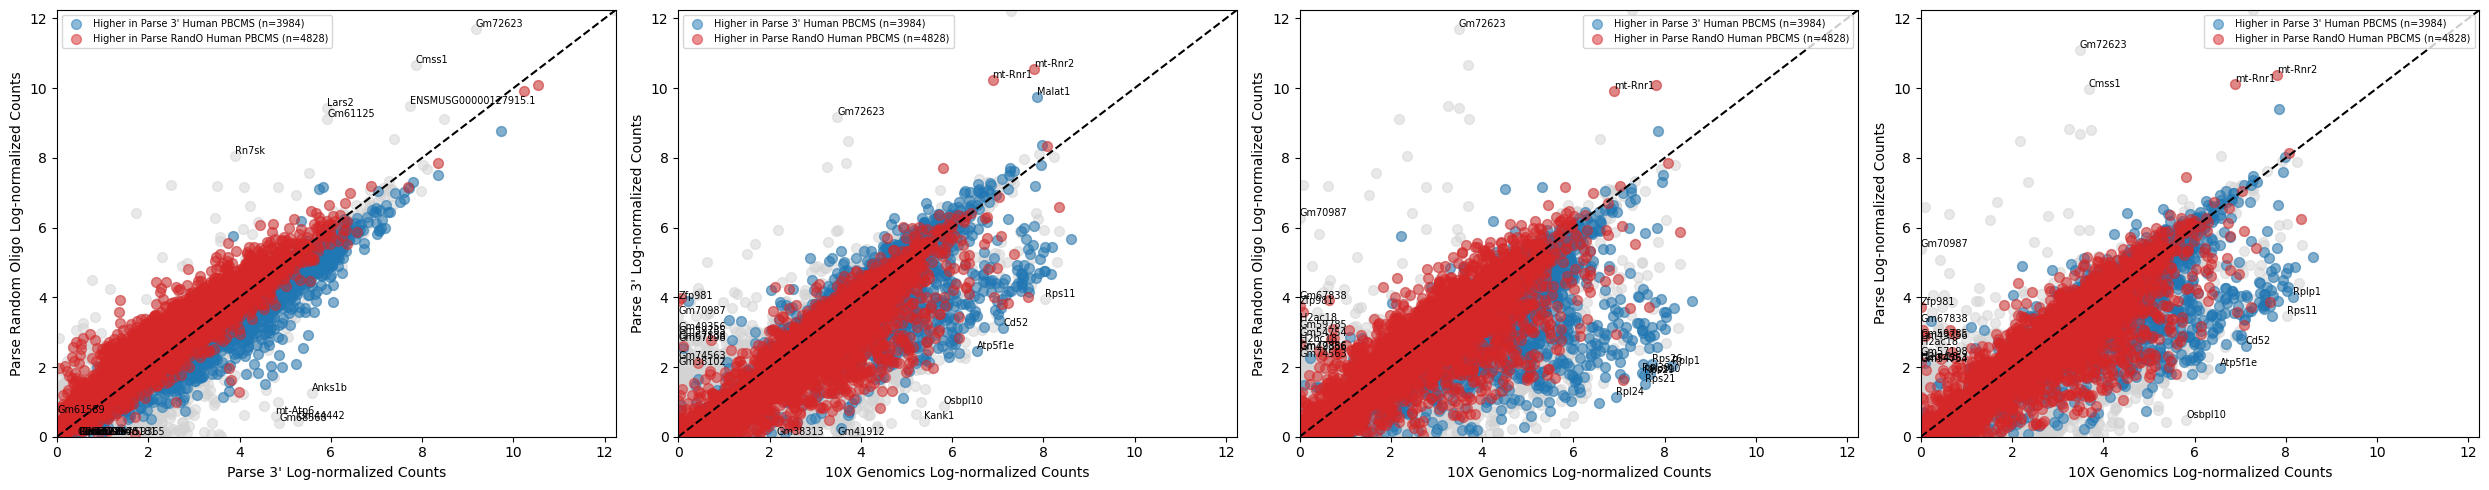

In [28]:
results= pd.read_csv(str(PROJECT_DIR / "Notebooks/Comparisons/PolyTvRandO/results.csv"))

plotting.compare_by_de(
    compare_dfs, comparisons,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("Parse 3' Human PBCMS", "Parse RandO Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

In [29]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)